In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns


import time
import math
import random
import re
import os
import sys


from utils.util import find_files_with_extension
from utils.util import  get_dataframe_from_filepath,calculate_statistics, extract_unique_mbps_and_ms
from utils.util import remove_outliers_iqr, comma_format, create_directory_if_not_exists,print_rtt_stats,save_rtt_stats,return_rtt_stats

In [2]:
# Load data
mainpth="../data/data_2025-04-11"

graph_directory = os.path.join(mainpth, "Graphs")
create_directory_if_not_exists(graph_directory)

stats_directory = os.path.join(mainpth, "Stats")
create_directory_if_not_exists(stats_directory)


folderpaths = [mainpth+'/client1_data',mainpth+'/client2_data']
filenames, filepaths, filedict = find_files_with_extension(folderpaths, '.log')


Directory already exists: ../data/data_2025-04-11\Graphs
Directory already exists: ../data/data_2025-04-11\Stats


In [3]:
filedict

{'1_dualpi2_100Mbps_0ms_ecn_tcp_newreno_src1.siftr.log': '../data/data_2025-04-11/client1_data\\1_dualpi2_100Mbps_0ms_ecn_tcp_newreno_src1.siftr.log',
 '1_dualpi2_100Mbps_10ms_ecn_tcp_newreno_src1.siftr.log': '../data/data_2025-04-11/client1_data\\1_dualpi2_100Mbps_10ms_ecn_tcp_newreno_src1.siftr.log',
 '1_dualpi2_100Mbps_20ms_ecn_tcp_newreno_src1.siftr.log': '../data/data_2025-04-11/client1_data\\1_dualpi2_100Mbps_20ms_ecn_tcp_newreno_src1.siftr.log',
 '1_dualpi2_100Mbps_5ms_ecn_tcp_newreno_src1.siftr.log': '../data/data_2025-04-11/client1_data\\1_dualpi2_100Mbps_5ms_ecn_tcp_newreno_src1.siftr.log',
 '1_dualpi2_10Mbps_0ms_ecn_tcp_newreno_src1.siftr.log': '../data/data_2025-04-11/client1_data\\1_dualpi2_10Mbps_0ms_ecn_tcp_newreno_src1.siftr.log',
 '1_dualpi2_10Mbps_10ms_ecn_tcp_newreno_src1.siftr.log': '../data/data_2025-04-11/client1_data\\1_dualpi2_10Mbps_10ms_ecn_tcp_newreno_src1.siftr.log',
 '1_dualpi2_10Mbps_20ms_ecn_tcp_newreno_src1.siftr.log': '../data/data_2025-04-11/client1_da

In [4]:
folderpaths

['../data/data_2025-04-11/client1_data',
 '../data/data_2025-04-11/client2_data']

In [5]:
# Call the function and print unique combinations
unique_combinations = extract_unique_mbps_and_ms(folderpaths)
print("Unique Mbps and ms Combinations:")
for mbps, ms in sorted(unique_combinations):
    print(f'{mbps} Mbps, {ms} ms')


Unique Mbps and ms Combinations:
10 Mbps, 0 ms
10 Mbps, 10 ms
10 Mbps, 20 ms
10 Mbps, 5 ms
100 Mbps, 0 ms
100 Mbps, 10 ms
100 Mbps, 20 ms
100 Mbps, 5 ms
150 Mbps, 0 ms
150 Mbps, 10 ms
150 Mbps, 20 ms
150 Mbps, 5 ms
20 Mbps, 0 ms
20 Mbps, 10 ms
20 Mbps, 20 ms
20 Mbps, 5 ms


In [6]:
mbps , ms = list(unique_combinations)[0]
net_settings = f'{mbps}_Mbps_{ms}_ms'
print(net_settings)

100_Mbps_10_ms


In [7]:
df=get_dataframe_from_filepath(filepaths[0])
df['ForeignPort'].unique()

../data/data_2025-04-11/client1_data\1_dualpi2_100Mbps_0ms_ecn_tcp_newreno_src1.siftr.log


array(['53854', '53781', '53787', '53789', '5102', '5101', '50478'],
      dtype=object)

In [8]:
unique_scenarios_dict={}
for index in range(len(filenames)):
    scenario = "_".join(filenames[index].split('_')[:5])
    if "l4s" in scenario:
        scenario = "_".join(filenames[index].split('_')[:4])
    if scenario in unique_scenarios_dict:
        unique_scenarios_dict[scenario].append(filedict[filenames[index]])
    else:
        unique_scenarios_dict[scenario]=[filedict[filenames[index]]]


In [9]:
unique_scenarios_dict

{'1_dualpi2_100Mbps_0ms_ecn': ['../data/data_2025-04-11/client1_data\\1_dualpi2_100Mbps_0ms_ecn_tcp_newreno_src1.siftr.log',
  '../data/data_2025-04-11/client2_data\\1_dualpi2_100Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log'],
 '1_dualpi2_100Mbps_10ms_ecn': ['../data/data_2025-04-11/client1_data\\1_dualpi2_100Mbps_10ms_ecn_tcp_newreno_src1.siftr.log',
  '../data/data_2025-04-11/client2_data\\1_dualpi2_100Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log'],
 '1_dualpi2_100Mbps_20ms_ecn': ['../data/data_2025-04-11/client1_data\\1_dualpi2_100Mbps_20ms_ecn_tcp_newreno_src1.siftr.log',
  '../data/data_2025-04-11/client2_data\\1_dualpi2_100Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log'],
 '1_dualpi2_100Mbps_5ms_ecn': ['../data/data_2025-04-11/client1_data\\1_dualpi2_100Mbps_5ms_ecn_tcp_newreno_src1.siftr.log',
  '../data/data_2025-04-11/client2_data\\1_dualpi2_100Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log'],
 '1_dualpi2_10Mbps_0ms_ecn': ['../data/data_2025-04-11/client1_data\\1_dualpi2_10Mbps_0ms_ecn_tcp_newreno_src1.sif

In [10]:
from utils.plotter import  plot_siftr_graph


Start New Scenario
1_dualpi2_100Mbps_0ms_ecn
['../data/data_2025-04-11/client1_data\\1_dualpi2_100Mbps_0ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\1_dualpi2_100Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\1_dualpi2_100Mbps_0ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\1_dualpi2_100Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\1_dualpi2_100Mbps_0ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\1_dualpi2_100Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 1_dualpi2_100Mbps_0ms_ecn:
Statistics for NEWRENO:
Median: 26.875
Mean: 37.64467111146179
25th Percentile: 22.187
75th Percentile: 30.937
Minimum: 3.125
Maximum: 328.125
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END RTT *-*-

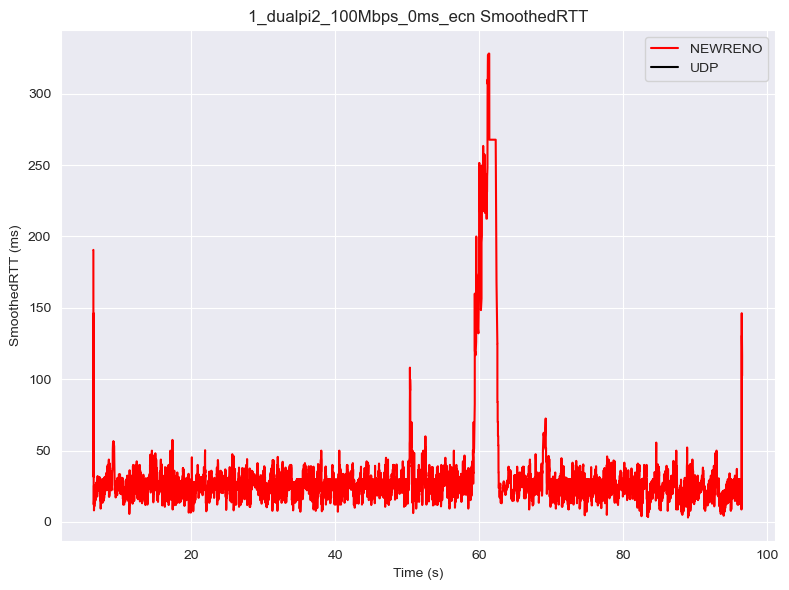

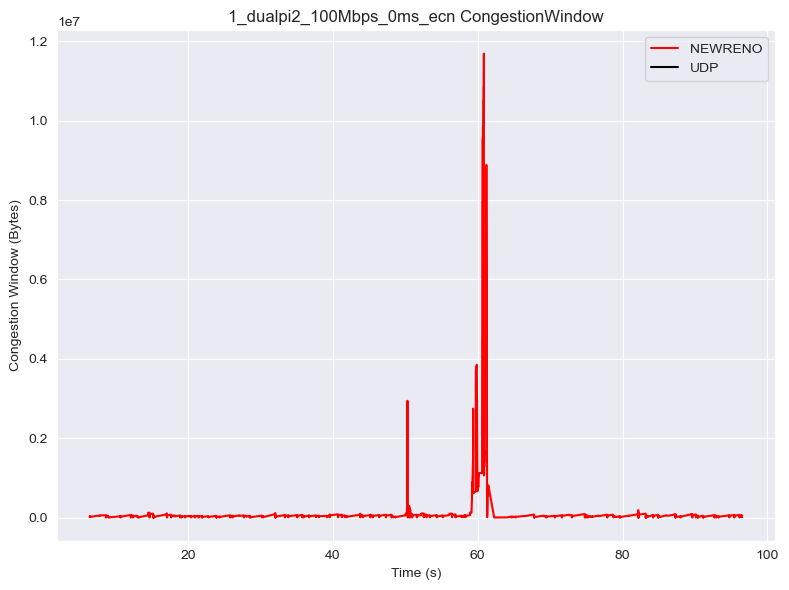


Start New Scenario
1_dualpi2_100Mbps_10ms_ecn
['../data/data_2025-04-11/client1_data\\1_dualpi2_100Mbps_10ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\1_dualpi2_100Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\1_dualpi2_100Mbps_10ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\1_dualpi2_100Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\1_dualpi2_100Mbps_10ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\1_dualpi2_100Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 1_dualpi2_100Mbps_10ms_ecn:
Statistics for NEWRENO:
Median: 200.0
Mean: 182.4254190186951
25th Percentile: 145.625
75th Percentile: 220.0
Minimum: 32.187
Maximum: 423.75
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END R

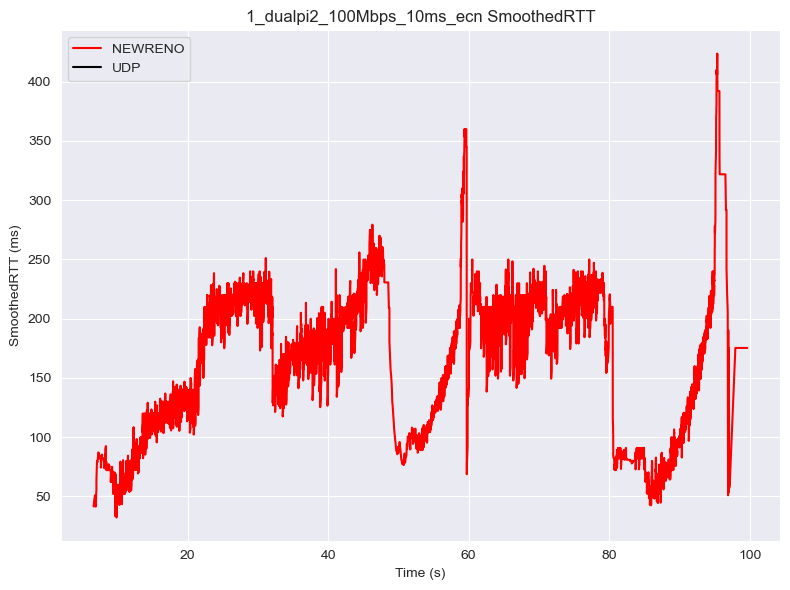

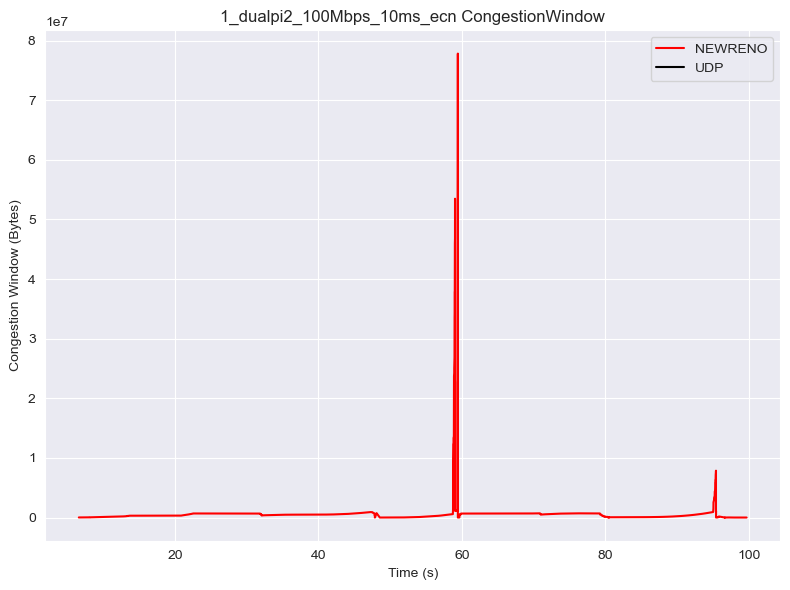


Start New Scenario
1_dualpi2_100Mbps_20ms_ecn
['../data/data_2025-04-11/client1_data\\1_dualpi2_100Mbps_20ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\1_dualpi2_100Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\1_dualpi2_100Mbps_20ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\1_dualpi2_100Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\1_dualpi2_100Mbps_20ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\1_dualpi2_100Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 1_dualpi2_100Mbps_20ms_ecn:
Statistics for NEWRENO:
Median: 202.187
Mean: 203.56901919962226
25th Percentile: 167.187
75th Percentile: 241.562
Minimum: 78.75
Maximum: 392.812
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan


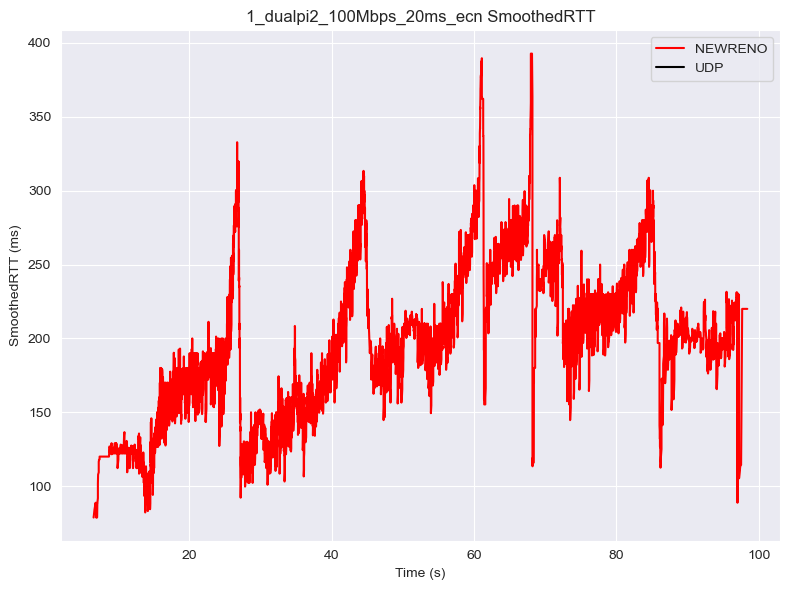

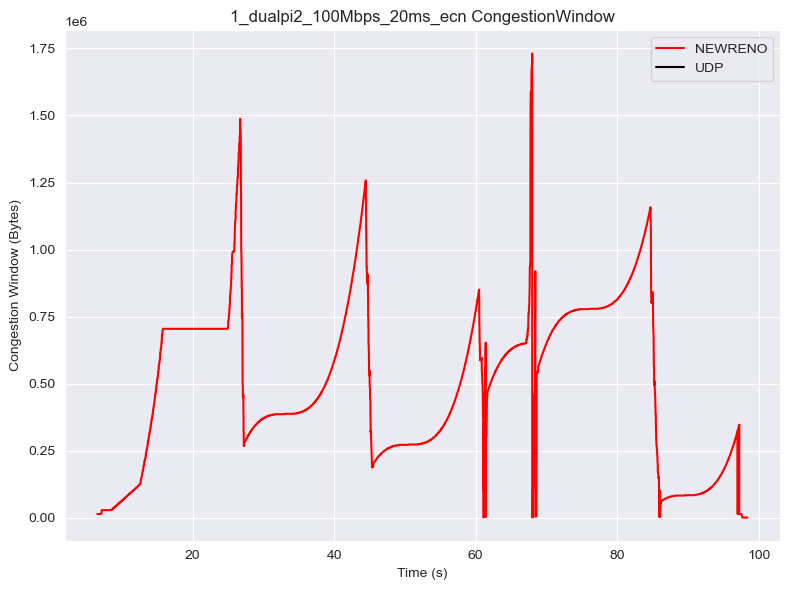


Start New Scenario
1_dualpi2_100Mbps_5ms_ecn
['../data/data_2025-04-11/client1_data\\1_dualpi2_100Mbps_5ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\1_dualpi2_100Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\1_dualpi2_100Mbps_5ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\1_dualpi2_100Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\1_dualpi2_100Mbps_5ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\1_dualpi2_100Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 1_dualpi2_100Mbps_5ms_ecn:
Statistics for NEWRENO:
Median: 28.75
Mean: 60.473290367607085
25th Percentile: 23.437
75th Percentile: 38.125
Minimum: 4.375
Maximum: 378.75
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END RTT *-*-*

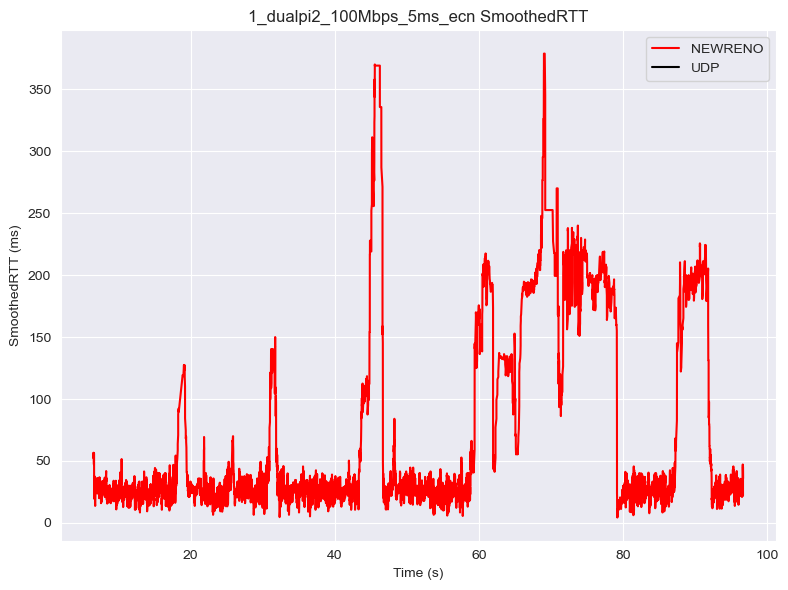

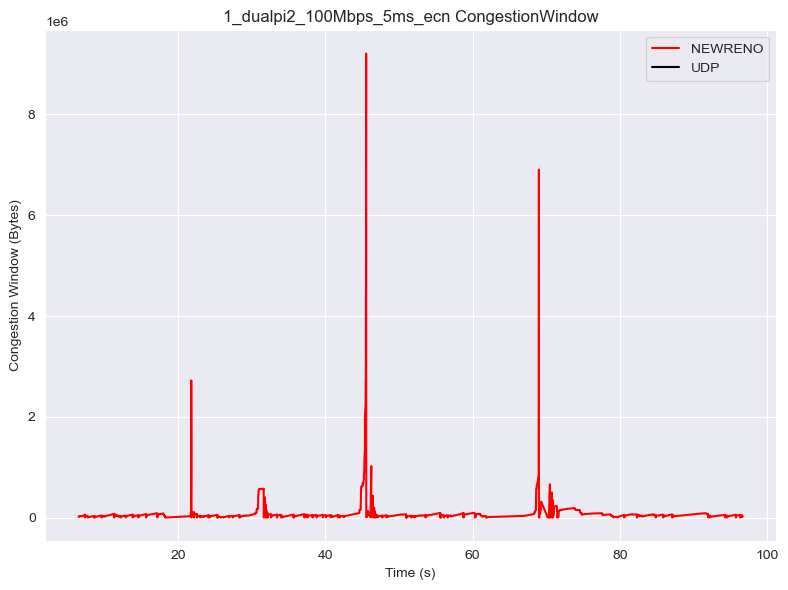


Start New Scenario
1_dualpi2_10Mbps_0ms_ecn
['../data/data_2025-04-11/client1_data\\1_dualpi2_10Mbps_0ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\1_dualpi2_10Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\1_dualpi2_10Mbps_0ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\1_dualpi2_10Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\1_dualpi2_10Mbps_0ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\1_dualpi2_10Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 1_dualpi2_10Mbps_0ms_ecn:
Statistics for NEWRENO:
Median: 201.562
Mean: 196.53659586244441
25th Percentile: 88.437
75th Percentile: 287.812
Minimum: 6.562
Maximum: 548.125
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END RTT *-*-*END 

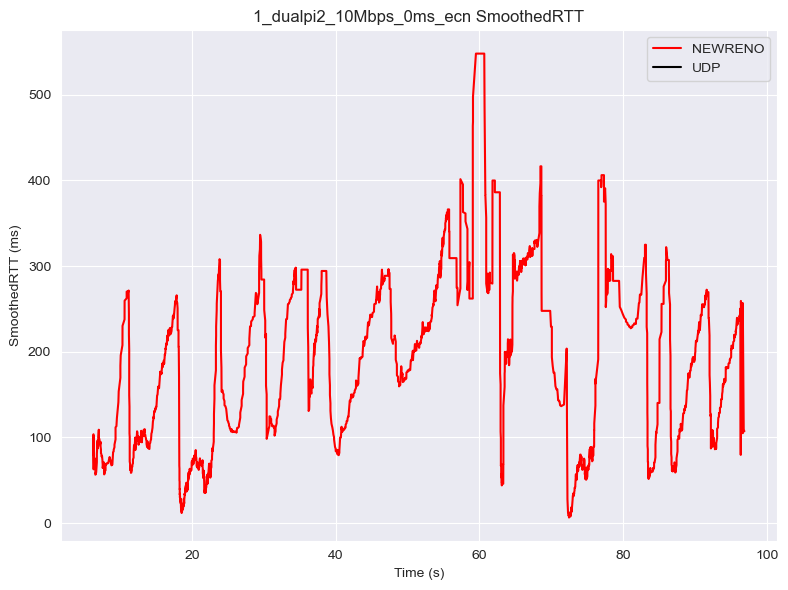

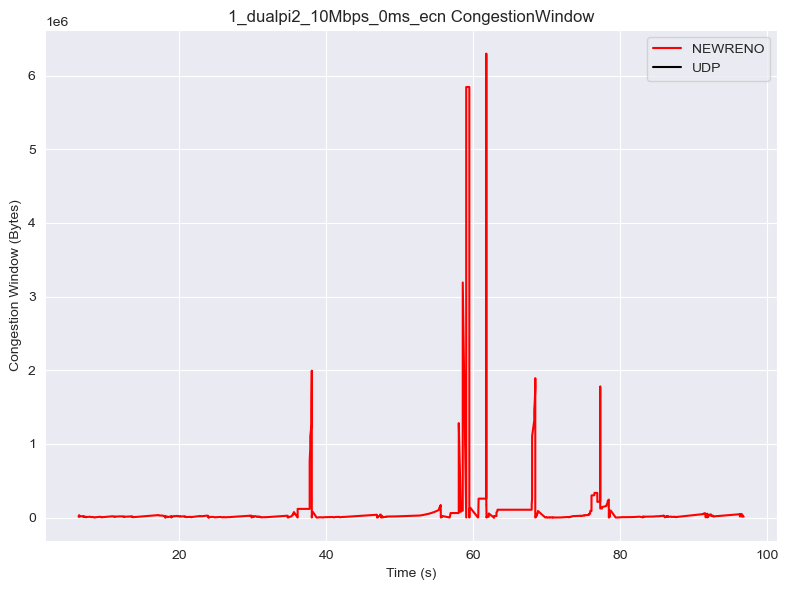


Start New Scenario
1_dualpi2_10Mbps_10ms_ecn
['../data/data_2025-04-11/client1_data\\1_dualpi2_10Mbps_10ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\1_dualpi2_10Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\1_dualpi2_10Mbps_10ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\1_dualpi2_10Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\1_dualpi2_10Mbps_10ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\1_dualpi2_10Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 1_dualpi2_10Mbps_10ms_ecn:
Statistics for NEWRENO:
Median: 267.9685
Mean: 263.83386559269053
25th Percentile: 220.0
75th Percentile: 309.687
Minimum: 88.75
Maximum: 480.625
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END RTT *

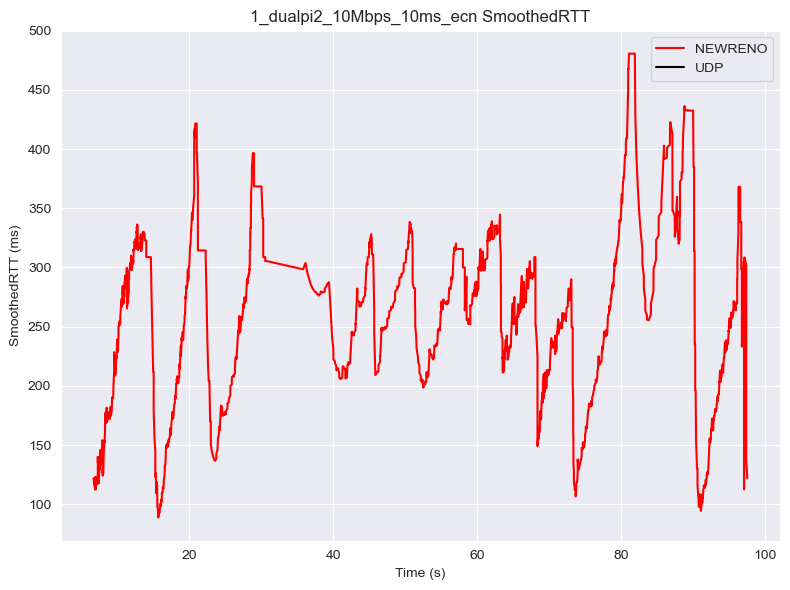

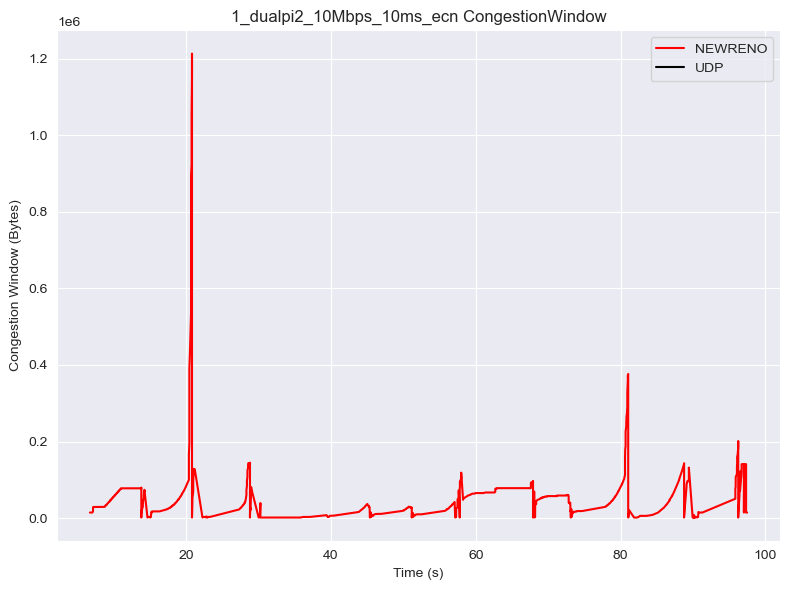


Start New Scenario
1_dualpi2_10Mbps_20ms_ecn
['../data/data_2025-04-11/client1_data\\1_dualpi2_10Mbps_20ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\1_dualpi2_10Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\1_dualpi2_10Mbps_20ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\1_dualpi2_10Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\1_dualpi2_10Mbps_20ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\1_dualpi2_10Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 1_dualpi2_10Mbps_20ms_ecn:
Statistics for NEWRENO:
Median: 273.125
Mean: 279.9746077560434
25th Percentile: 216.25
75th Percentile: 327.187
Minimum: 115.937
Maximum: 621.25
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END RTT *

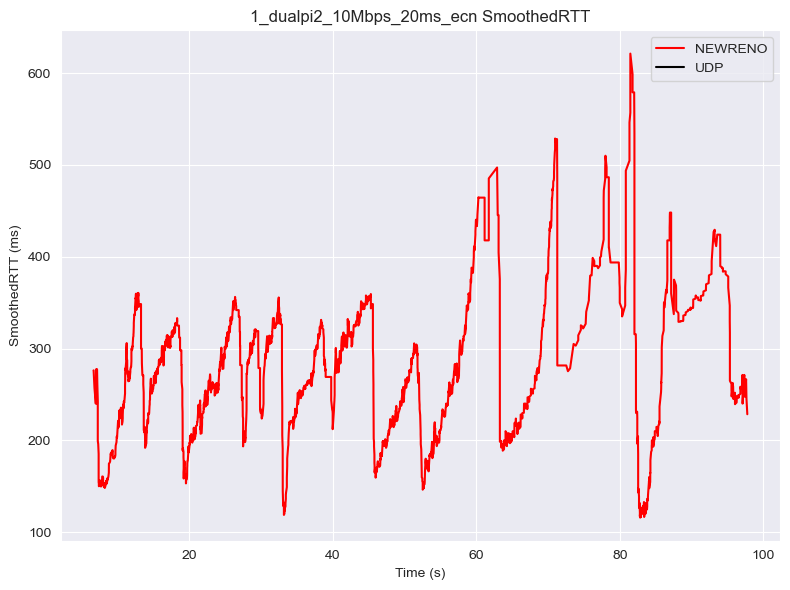

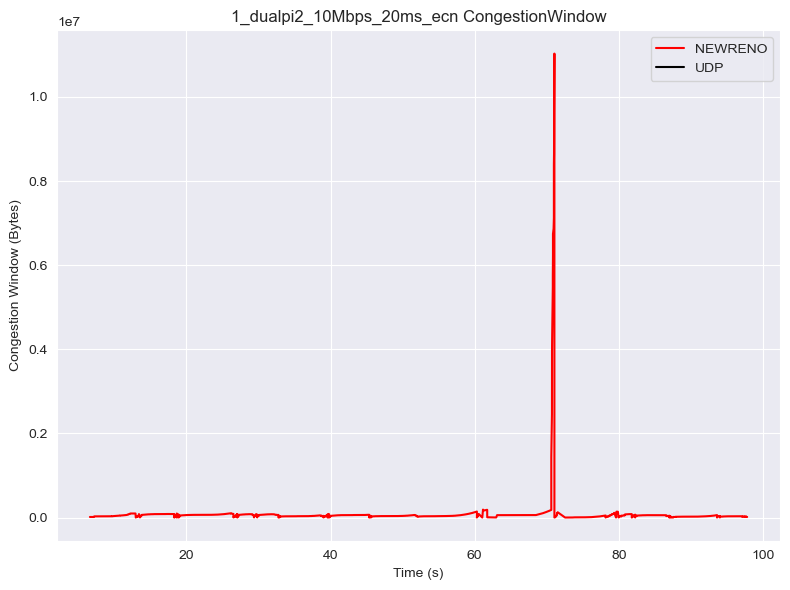


Start New Scenario
1_dualpi2_10Mbps_5ms_ecn
['../data/data_2025-04-11/client1_data\\1_dualpi2_10Mbps_5ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\1_dualpi2_10Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\1_dualpi2_10Mbps_5ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\1_dualpi2_10Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\1_dualpi2_10Mbps_5ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\1_dualpi2_10Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 1_dualpi2_10Mbps_5ms_ecn:
Statistics for NEWRENO:
Median: 201.562
Mean: 196.26858188715028
25th Percentile: 109.687
75th Percentile: 249.687
Minimum: 22.187
Maximum: 672.5
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END RTT *-*-*END 

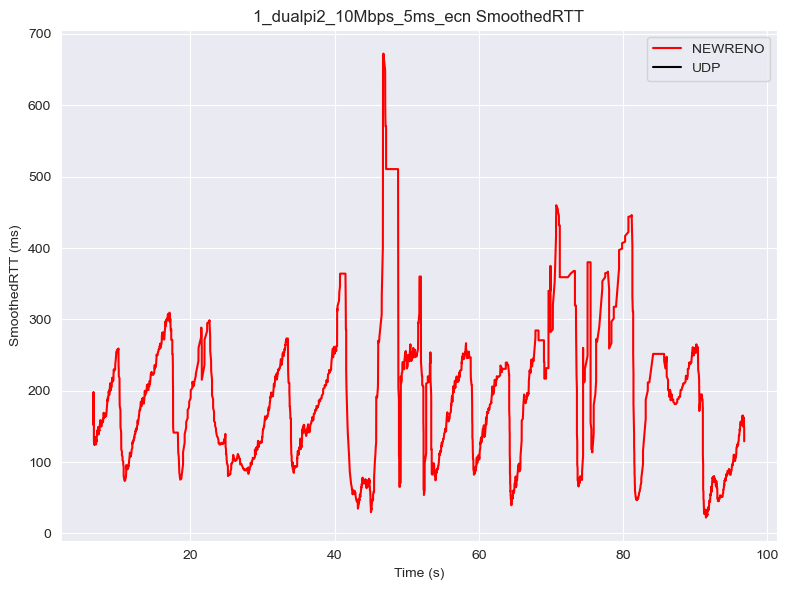

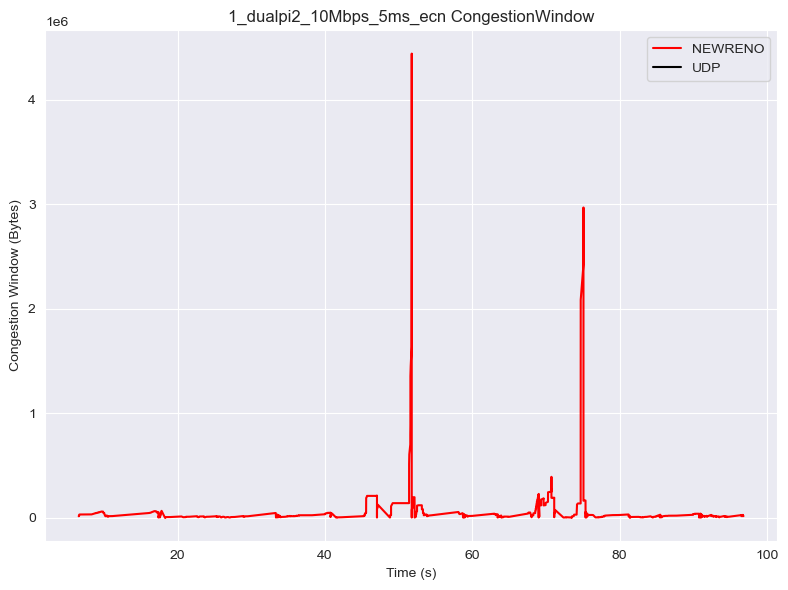


Start New Scenario
1_dualpi2_150Mbps_0ms_ecn
['../data/data_2025-04-11/client1_data\\1_dualpi2_150Mbps_0ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\1_dualpi2_150Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\1_dualpi2_150Mbps_0ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\1_dualpi2_150Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\1_dualpi2_150Mbps_0ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\1_dualpi2_150Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 1_dualpi2_150Mbps_0ms_ecn:
Statistics for NEWRENO:
Median: 37.187
Mean: 95.68866269606532
25th Percentile: 21.562
75th Percentile: 179.062
Minimum: 2.187
Maximum: 420.0
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END RTT *-*-*

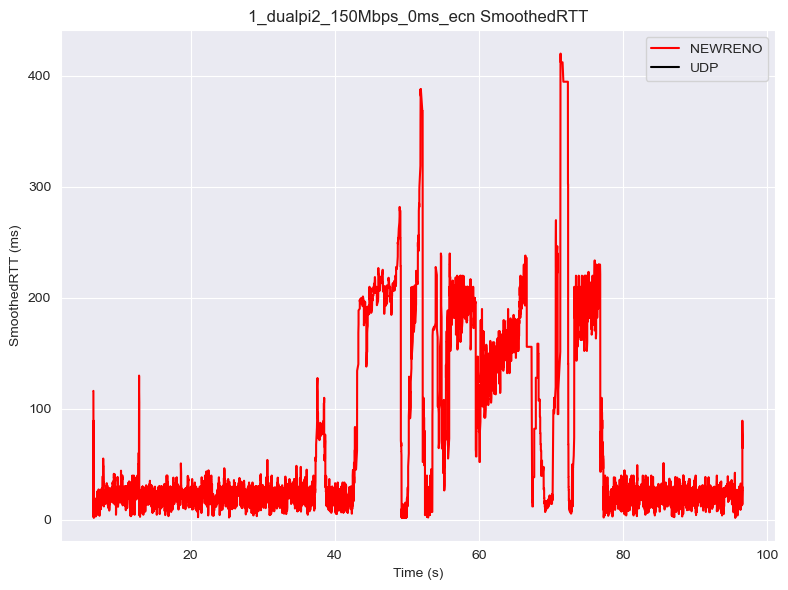

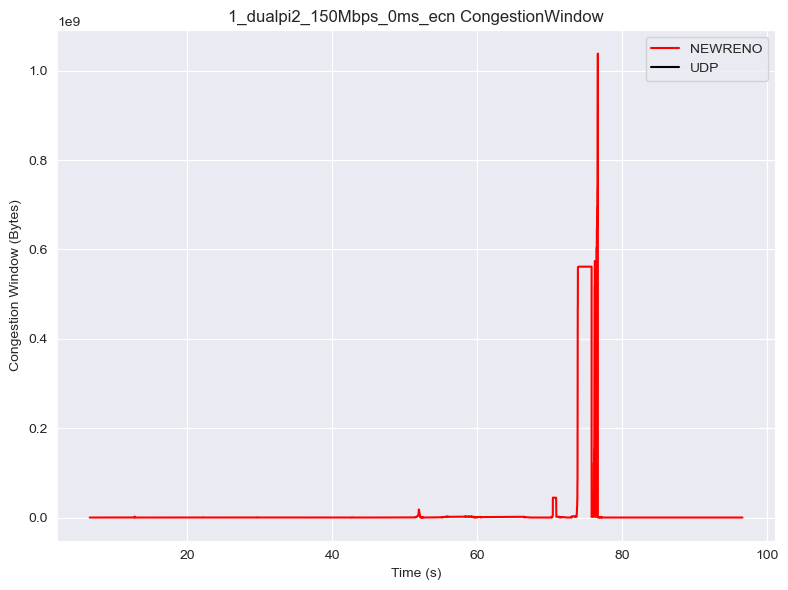


Start New Scenario
1_dualpi2_150Mbps_10ms_ecn
['../data/data_2025-04-11/client1_data\\1_dualpi2_150Mbps_10ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\1_dualpi2_150Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\1_dualpi2_150Mbps_10ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\1_dualpi2_150Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\1_dualpi2_150Mbps_10ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\1_dualpi2_150Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 1_dualpi2_150Mbps_10ms_ecn:
Statistics for NEWRENO:
Median: 130.0
Mean: 136.456349442255
25th Percentile: 106.25
75th Percentile: 171.25
Minimum: 35.312
Maximum: 237.5
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END RTT

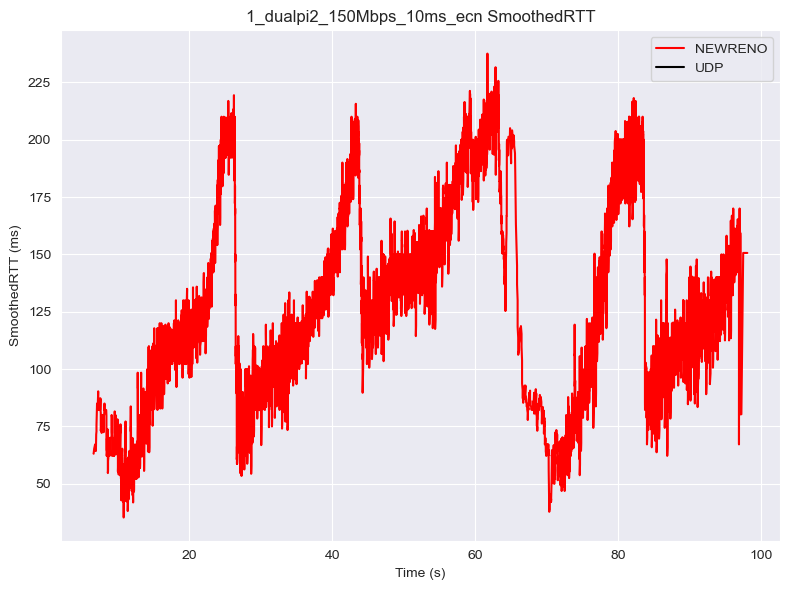

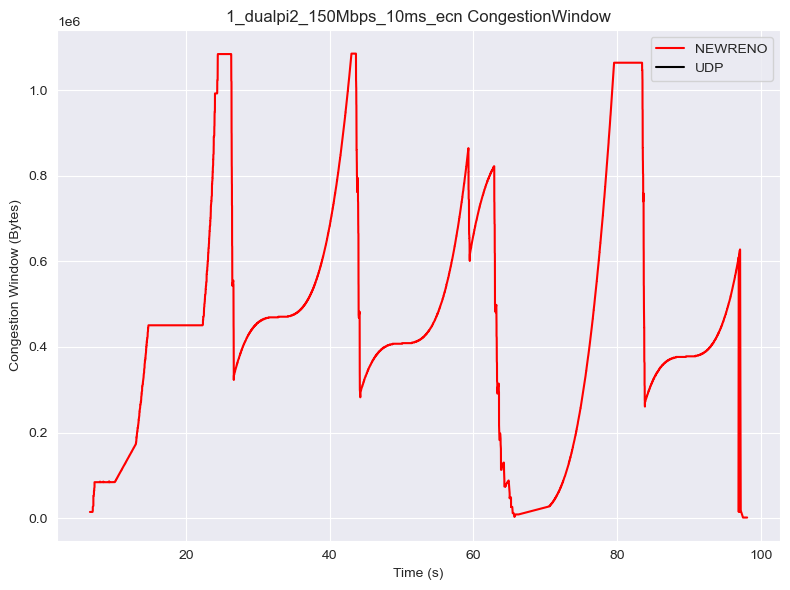


Start New Scenario
1_dualpi2_150Mbps_20ms_ecn
['../data/data_2025-04-11/client1_data\\1_dualpi2_150Mbps_20ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\1_dualpi2_150Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\1_dualpi2_150Mbps_20ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\1_dualpi2_150Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\1_dualpi2_150Mbps_20ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\1_dualpi2_150Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 1_dualpi2_150Mbps_20ms_ecn:
Statistics for NEWRENO:
Median: 201.25
Mean: 188.6100070545621
25th Percentile: 148.125
75th Percentile: 229.687
Minimum: 75.937
Maximum: 310.0
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END

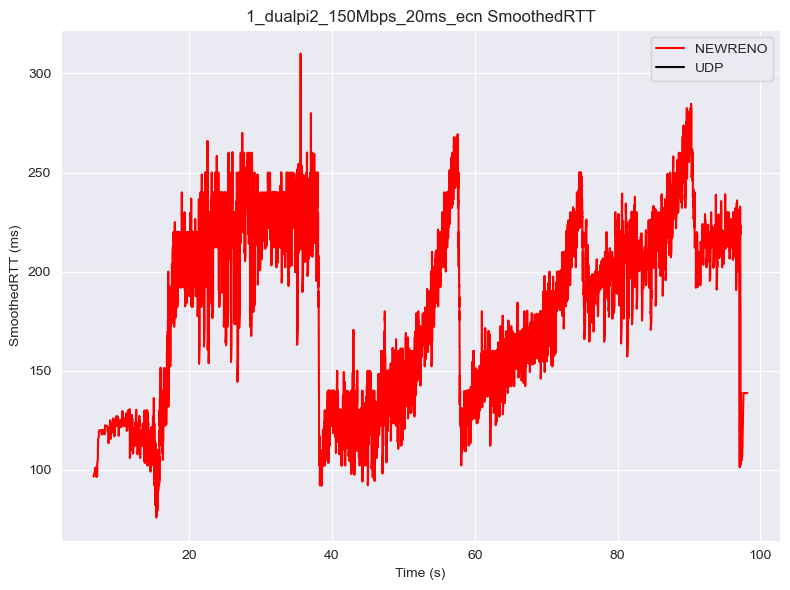

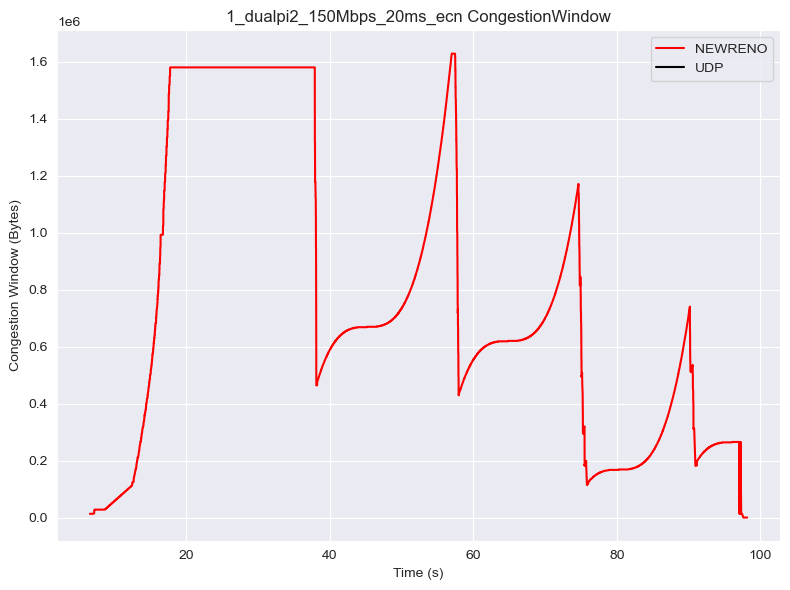


Start New Scenario
1_dualpi2_150Mbps_5ms_ecn
['../data/data_2025-04-11/client1_data\\1_dualpi2_150Mbps_5ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\1_dualpi2_150Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\1_dualpi2_150Mbps_5ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\1_dualpi2_150Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\1_dualpi2_150Mbps_5ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\1_dualpi2_150Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 1_dualpi2_150Mbps_5ms_ecn:
Statistics for NEWRENO:
Median: 22.187
Mean: 23.750908817711995
25th Percentile: 17.812
75th Percentile: 27.812
Minimum: 2.187
Maximum: 221.25
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END RTT *-*-

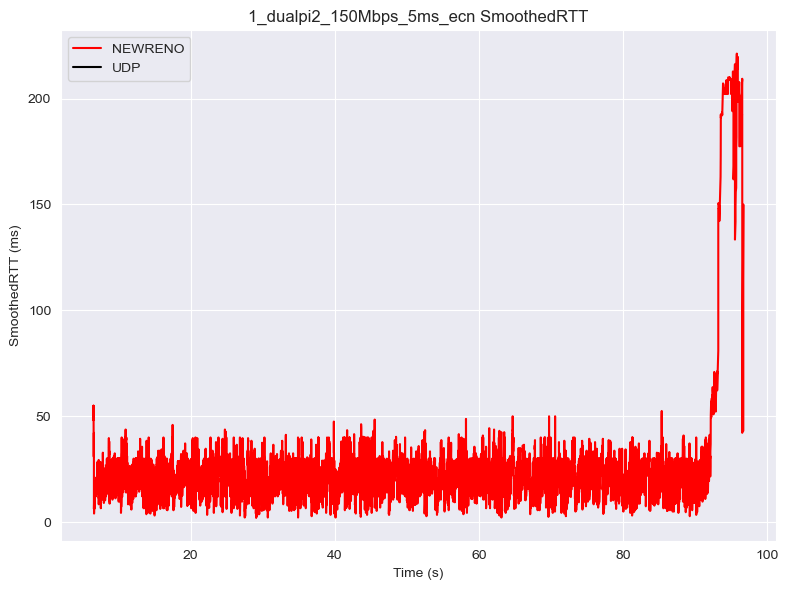

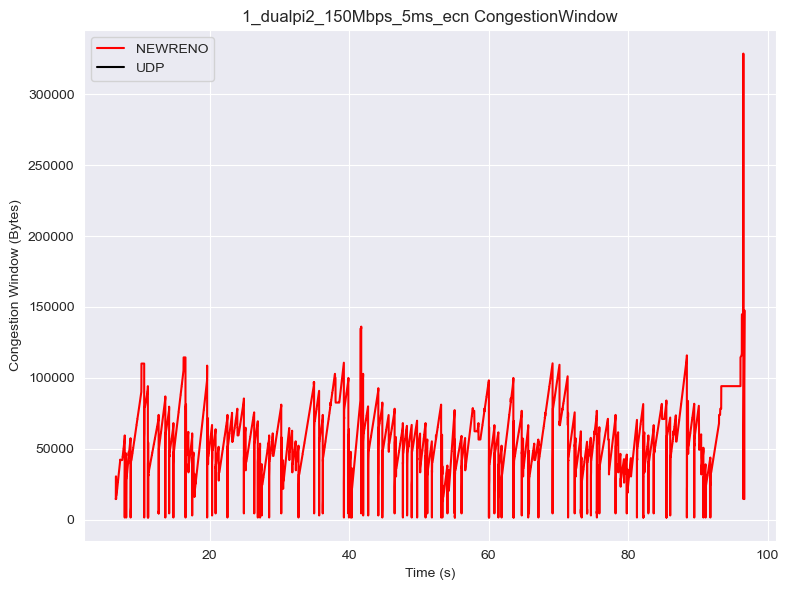


Start New Scenario
1_dualpi2_20Mbps_0ms_ecn
['../data/data_2025-04-11/client1_data\\1_dualpi2_20Mbps_0ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\1_dualpi2_20Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\1_dualpi2_20Mbps_0ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\1_dualpi2_20Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\1_dualpi2_20Mbps_0ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\1_dualpi2_20Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 1_dualpi2_20Mbps_0ms_ecn:
Statistics for NEWRENO:
Median: 110.0
Mean: 163.59592274216942
25th Percentile: 65.937
75th Percentile: 237.187
Minimum: 4.062
Maximum: 640.0
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END RTT *-*-*END RTT 

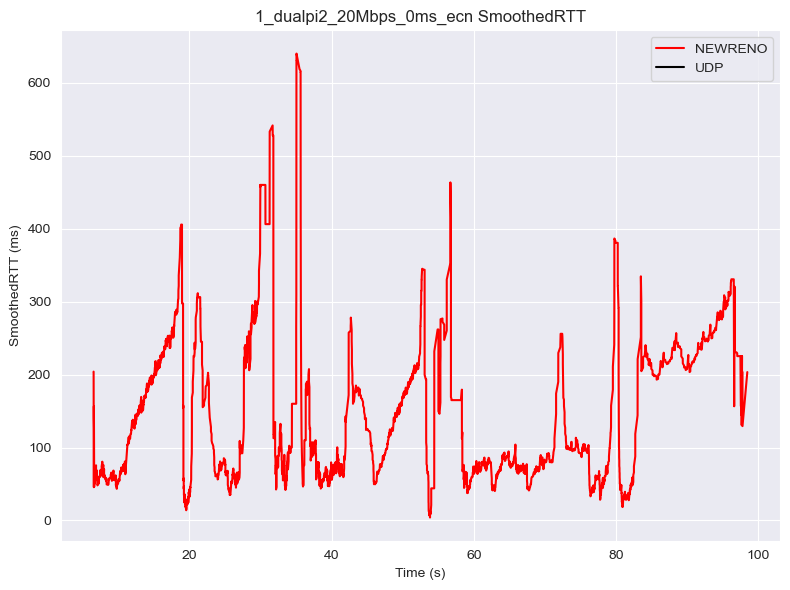

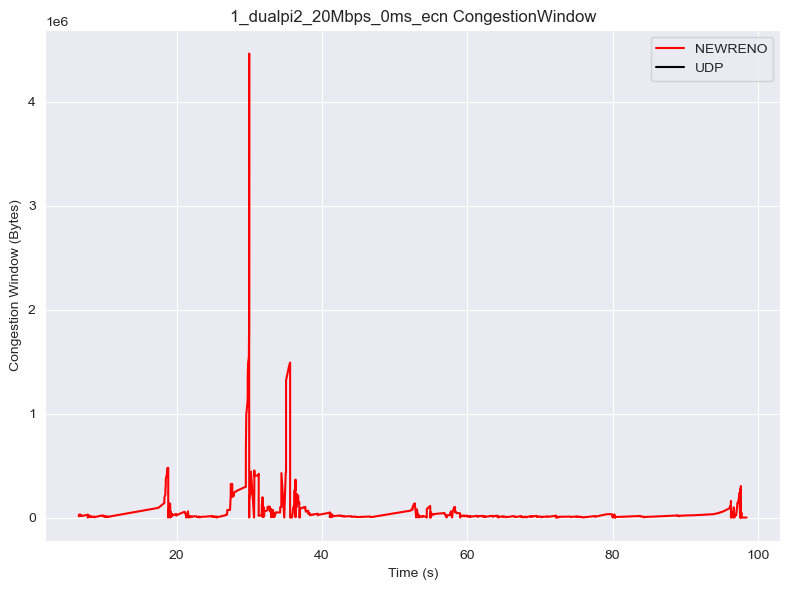


Start New Scenario
1_dualpi2_20Mbps_10ms_ecn
['../data/data_2025-04-11/client1_data\\1_dualpi2_20Mbps_10ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\1_dualpi2_20Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\1_dualpi2_20Mbps_10ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\1_dualpi2_20Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\1_dualpi2_20Mbps_10ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\1_dualpi2_20Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 1_dualpi2_20Mbps_10ms_ecn:
Statistics for NEWRENO:
Median: 250.937
Mean: 246.22377987836495
25th Percentile: 220.0
75th Percentile: 282.187
Minimum: 70.312
Maximum: 383.437
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END RTT *

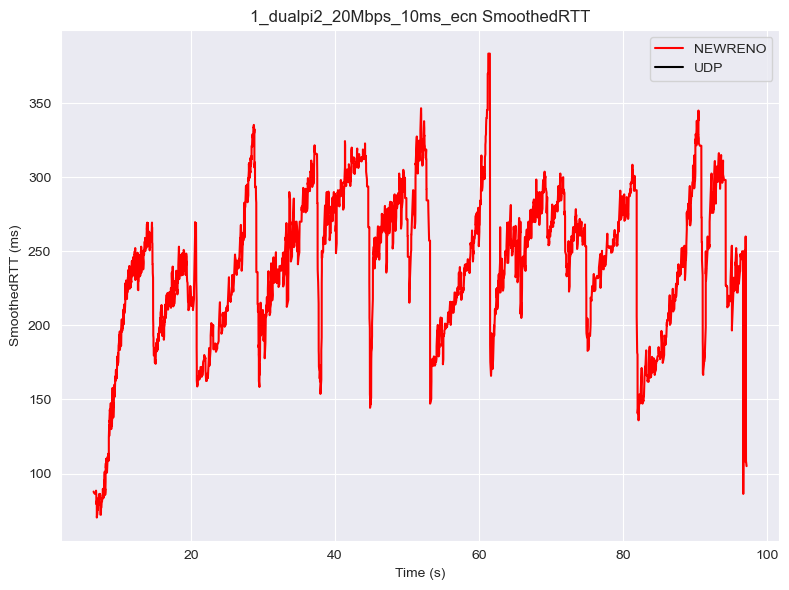

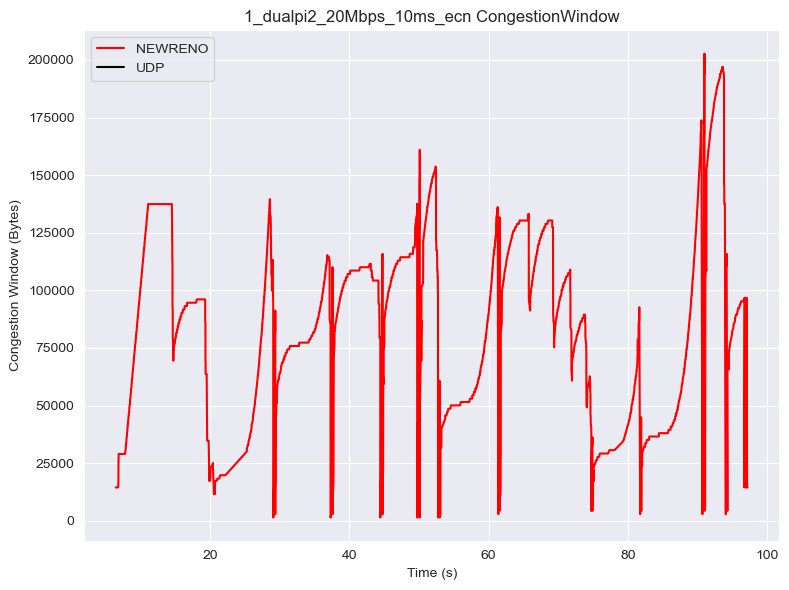


Start New Scenario
1_dualpi2_20Mbps_20ms_ecn
['../data/data_2025-04-11/client1_data\\1_dualpi2_20Mbps_20ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\1_dualpi2_20Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\1_dualpi2_20Mbps_20ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\1_dualpi2_20Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\1_dualpi2_20Mbps_20ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\1_dualpi2_20Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 1_dualpi2_20Mbps_20ms_ecn:
Statistics for NEWRENO:
Median: 262.812
Mean: 260.3705104054814
25th Percentile: 220.312
75th Percentile: 298.125
Minimum: 118.125
Maximum: 405.312
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END RTT

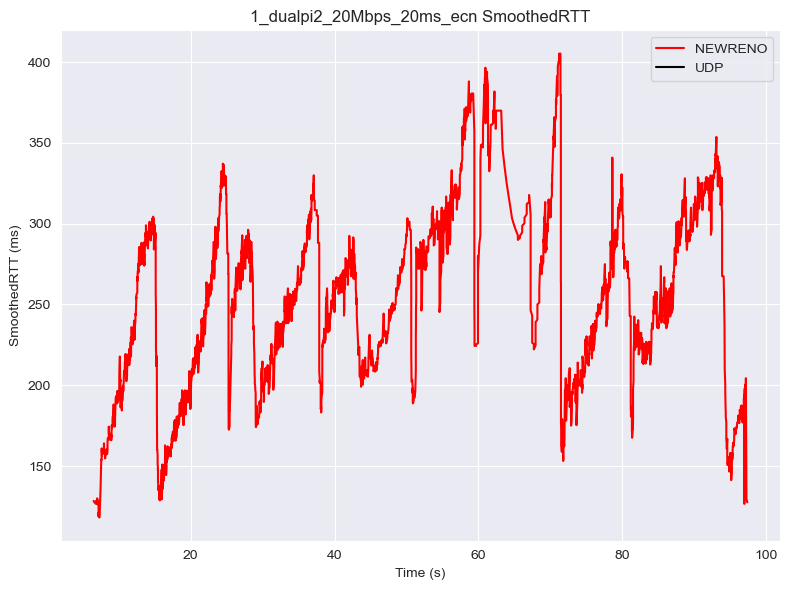

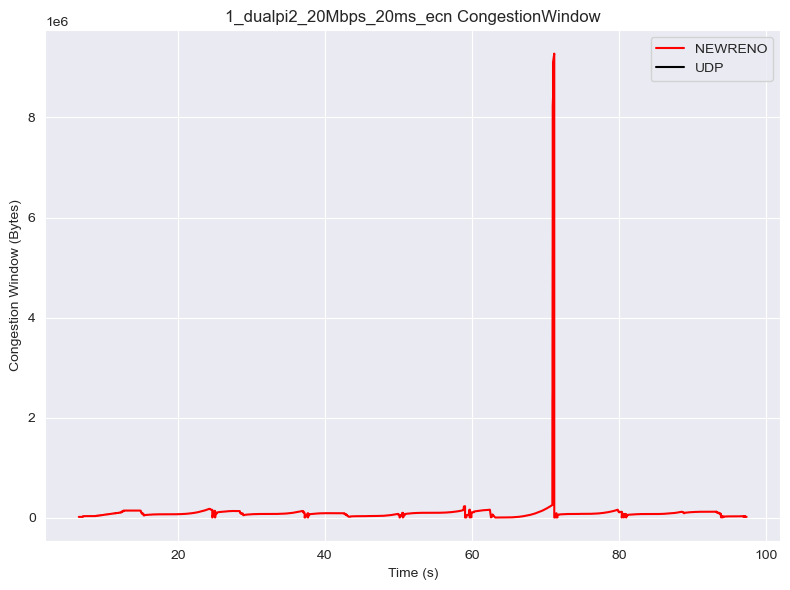


Start New Scenario
1_dualpi2_20Mbps_5ms_ecn
['../data/data_2025-04-11/client1_data\\1_dualpi2_20Mbps_5ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\1_dualpi2_20Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\1_dualpi2_20Mbps_5ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\1_dualpi2_20Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\1_dualpi2_20Mbps_5ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\1_dualpi2_20Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 1_dualpi2_20Mbps_5ms_ecn:
Statistics for NEWRENO:
Median: 153.125
Mean: 161.1472610745832
25th Percentile: 74.687
75th Percentile: 231.875
Minimum: 2.187
Maximum: 626.875
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END RTT *-*-*END R

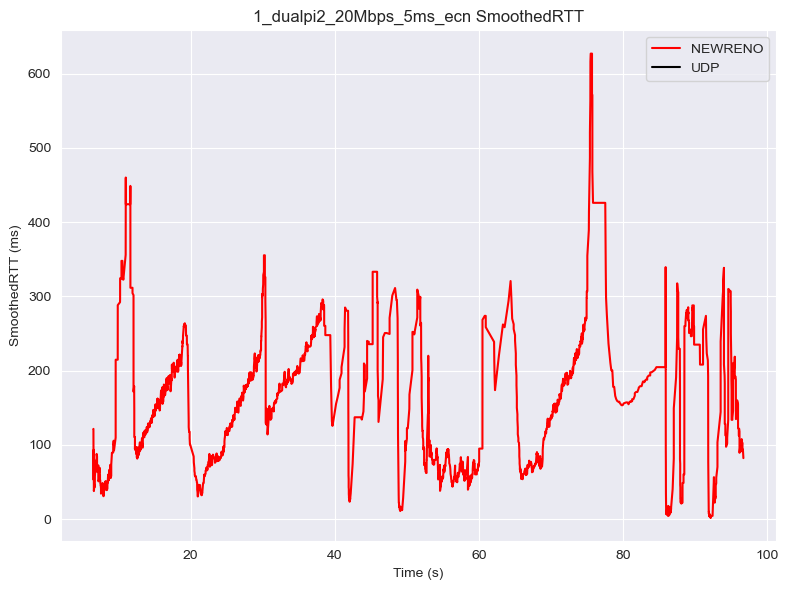

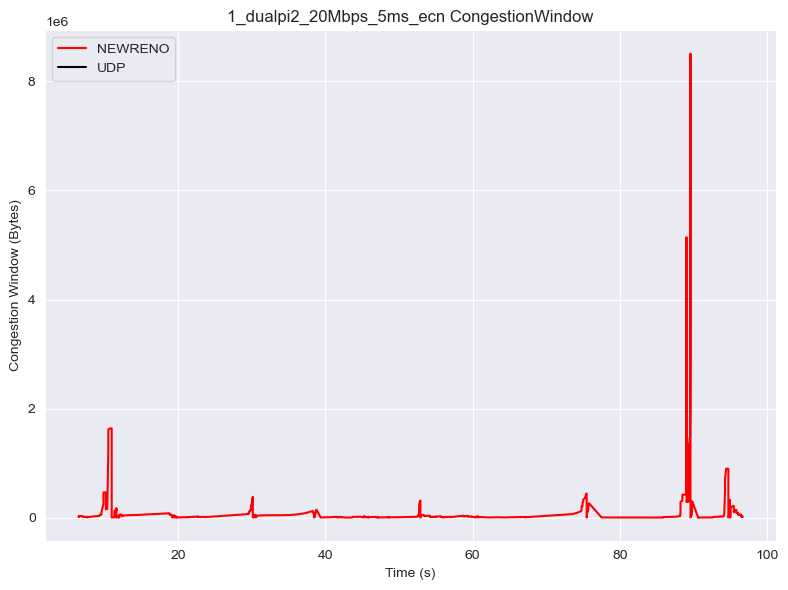


Start New Scenario
2_dualpi2_100Mbps_0ms_ecn
['../data/data_2025-04-11/client1_data\\2_dualpi2_100Mbps_0ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\2_dualpi2_100Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\2_dualpi2_100Mbps_0ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\2_dualpi2_100Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\2_dualpi2_100Mbps_0ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\2_dualpi2_100Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 2_dualpi2_100Mbps_0ms_ecn:
Statistics for NEWRENO:
Median: 28.437
Mean: 56.690395873732676
25th Percentile: 23.125
75th Percentile: 39.375
Minimum: 2.187
Maximum: 372.5
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END RTT *-*-*

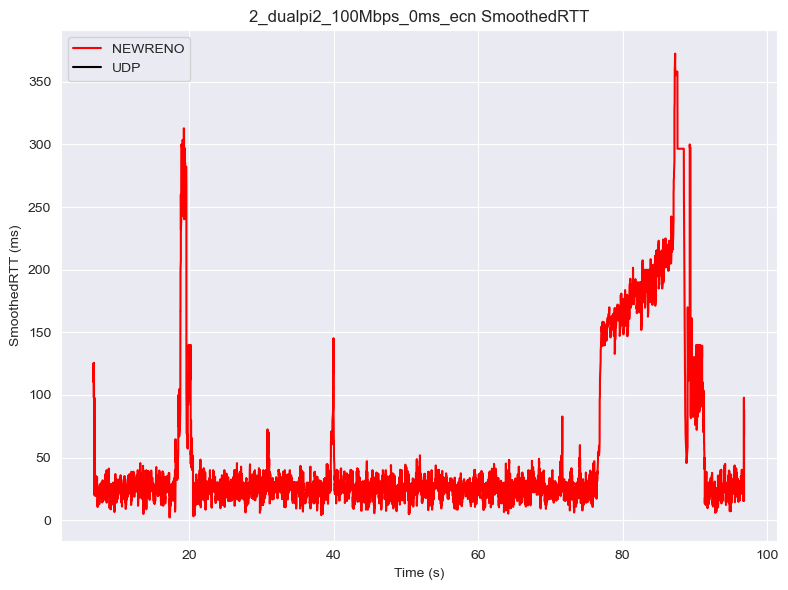

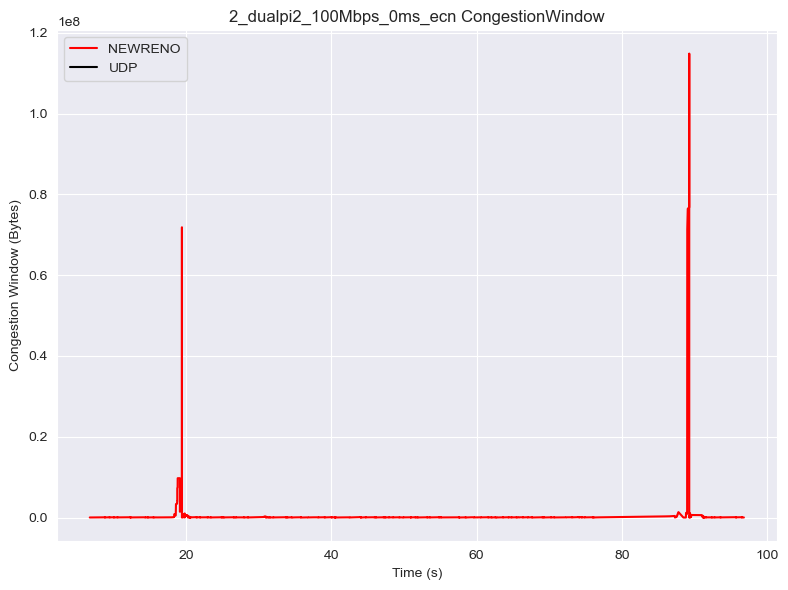


Start New Scenario
2_dualpi2_100Mbps_10ms_ecn
['../data/data_2025-04-11/client1_data\\2_dualpi2_100Mbps_10ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\2_dualpi2_100Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\2_dualpi2_100Mbps_10ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\2_dualpi2_100Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\2_dualpi2_100Mbps_10ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\2_dualpi2_100Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 2_dualpi2_100Mbps_10ms_ecn:
Statistics for NEWRENO:
Median: 154.062
Mean: 157.39994023949052
25th Percentile: 120.0
75th Percentile: 187.187
Minimum: 34.375
Maximum: 440.0
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END

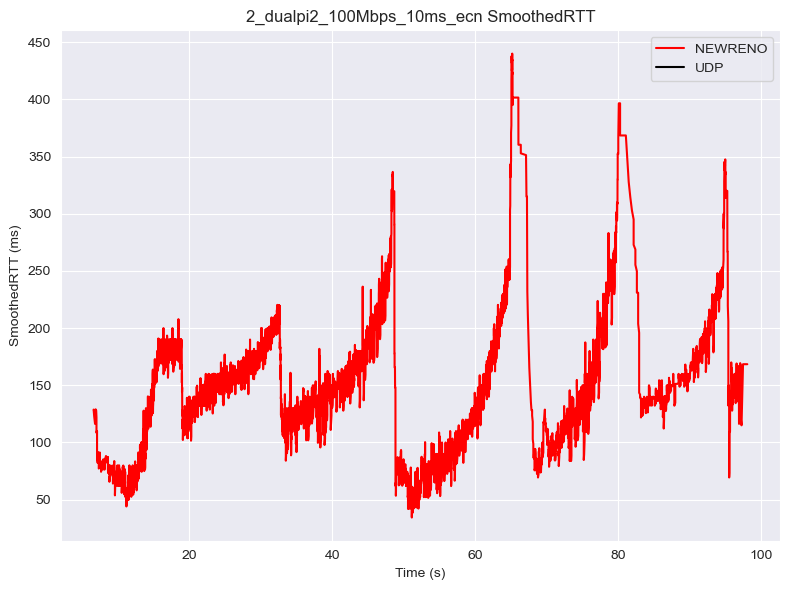

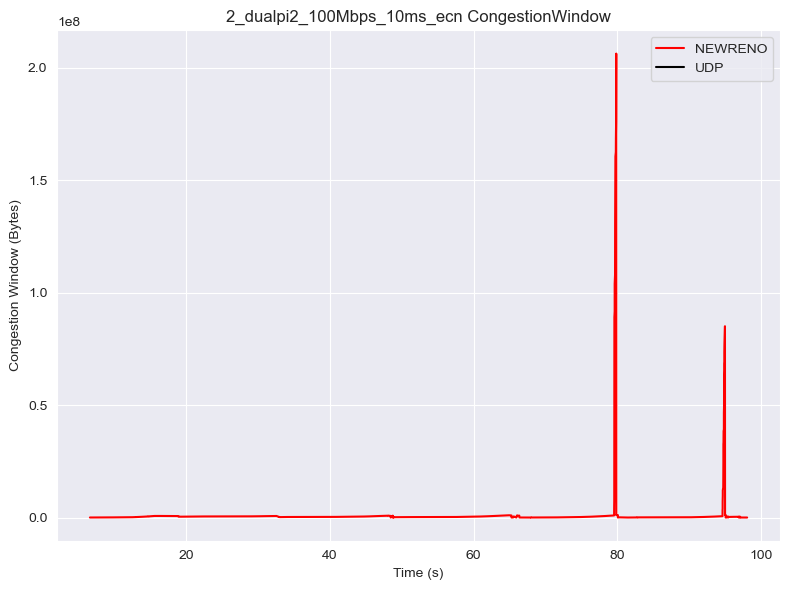


Start New Scenario
2_dualpi2_100Mbps_20ms_ecn
['../data/data_2025-04-11/client1_data\\2_dualpi2_100Mbps_20ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\2_dualpi2_100Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\2_dualpi2_100Mbps_20ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\2_dualpi2_100Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\2_dualpi2_100Mbps_20ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\2_dualpi2_100Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 2_dualpi2_100Mbps_20ms_ecn:
Statistics for NEWRENO:
Median: 197.812
Mean: 190.94589796228132
25th Percentile: 140.937
75th Percentile: 234.375
Minimum: 74.062
Maximum: 355.625
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan

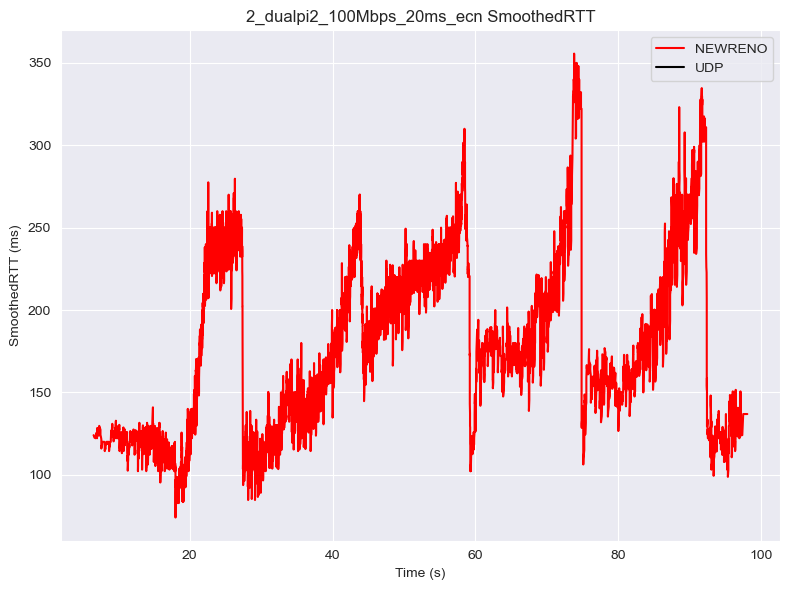

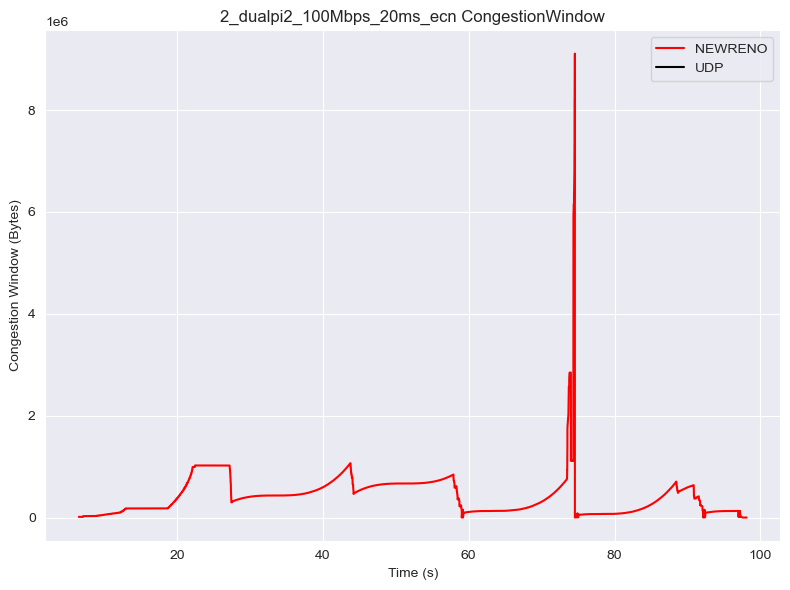


Start New Scenario
2_dualpi2_100Mbps_5ms_ecn
['../data/data_2025-04-11/client1_data\\2_dualpi2_100Mbps_5ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\2_dualpi2_100Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\2_dualpi2_100Mbps_5ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\2_dualpi2_100Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\2_dualpi2_100Mbps_5ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\2_dualpi2_100Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 2_dualpi2_100Mbps_5ms_ecn:
Statistics for NEWRENO:
Median: 24.062
Mean: 25.114039415411874
25th Percentile: 18.75
75th Percentile: 29.062
Minimum: 2.187
Maximum: 365.0
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END RTT *-*-*E

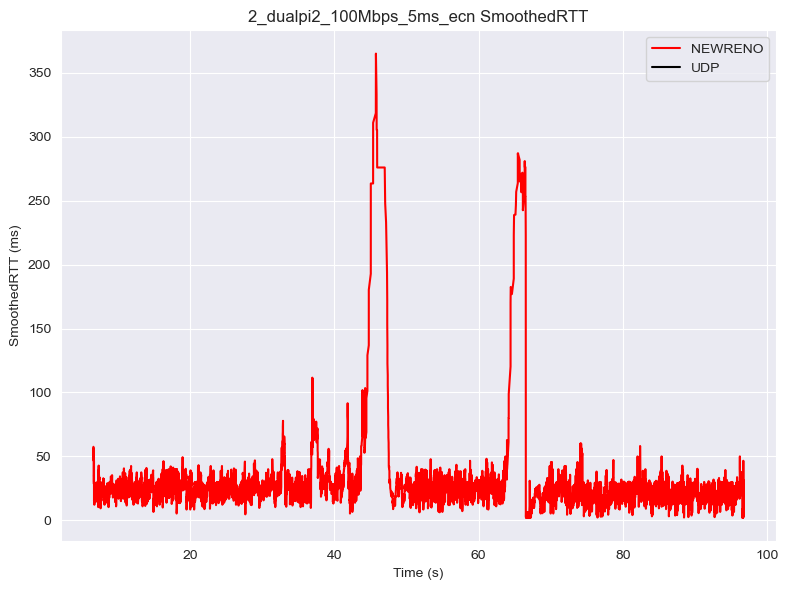

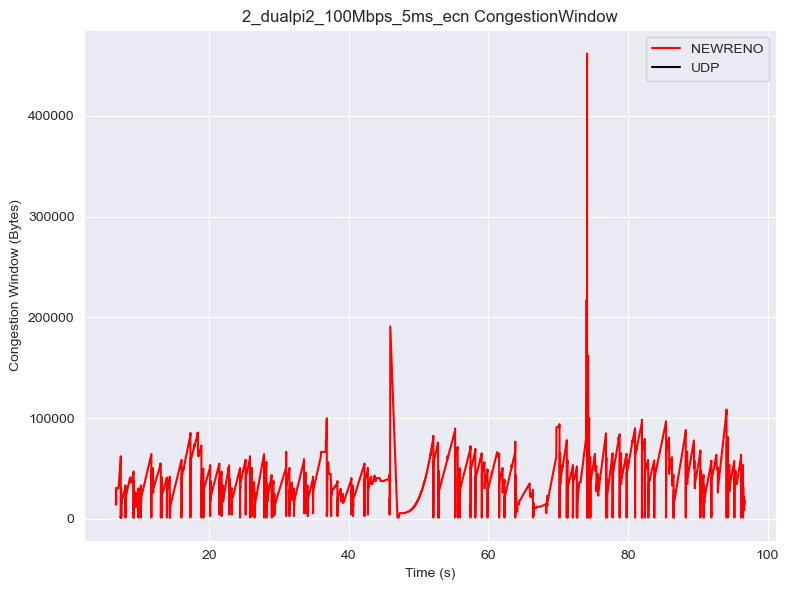


Start New Scenario
2_dualpi2_10Mbps_0ms_ecn
['../data/data_2025-04-11/client1_data\\2_dualpi2_10Mbps_0ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\2_dualpi2_10Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\2_dualpi2_10Mbps_0ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\2_dualpi2_10Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\2_dualpi2_10Mbps_0ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\2_dualpi2_10Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 2_dualpi2_10Mbps_0ms_ecn:
Statistics for NEWRENO:
Median: 190.625
Mean: 193.41398300687504
25th Percentile: 108.437
75th Percentile: 259.375
Minimum: 34.062
Maximum: 603.125
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END RTT *-*-*EN

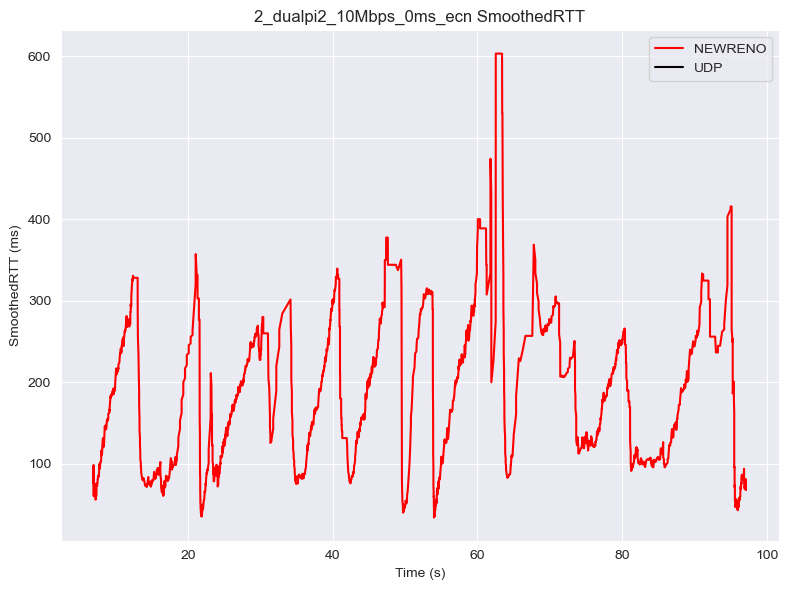

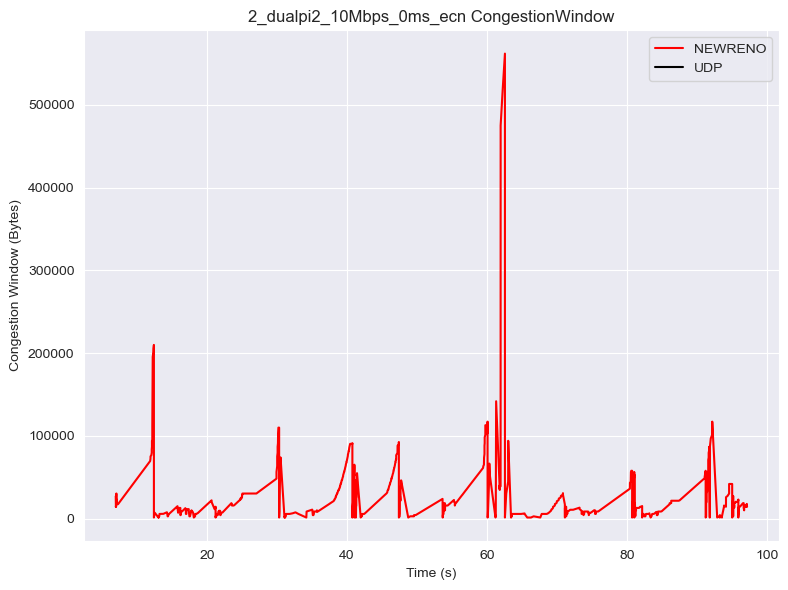


Start New Scenario
2_dualpi2_10Mbps_10ms_ecn
['../data/data_2025-04-11/client1_data\\2_dualpi2_10Mbps_10ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\2_dualpi2_10Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\2_dualpi2_10Mbps_10ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\2_dualpi2_10Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\2_dualpi2_10Mbps_10ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\2_dualpi2_10Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 2_dualpi2_10Mbps_10ms_ecn:
Statistics for NEWRENO:
Median: 230.625
Mean: 231.85982683560746
25th Percentile: 175.703
75th Percentile: 280.312
Minimum: 72.812
Maximum: 442.812
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END RTT

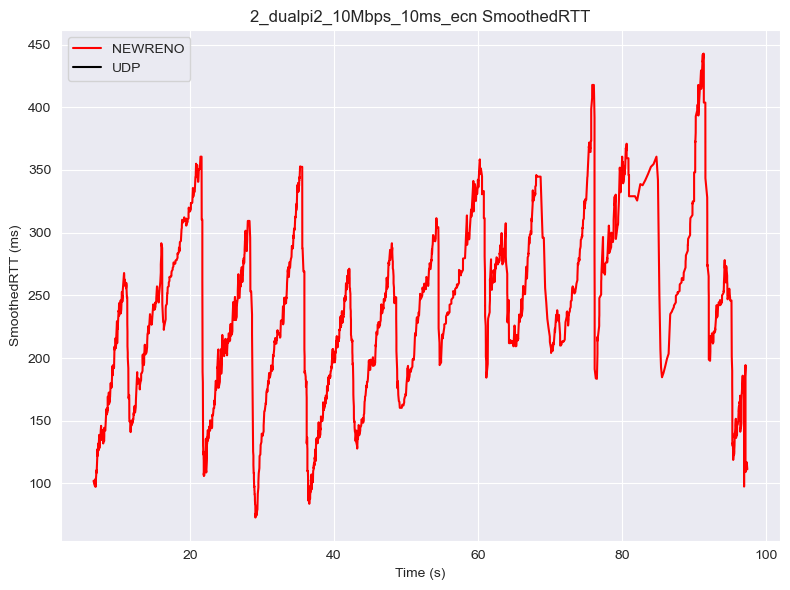

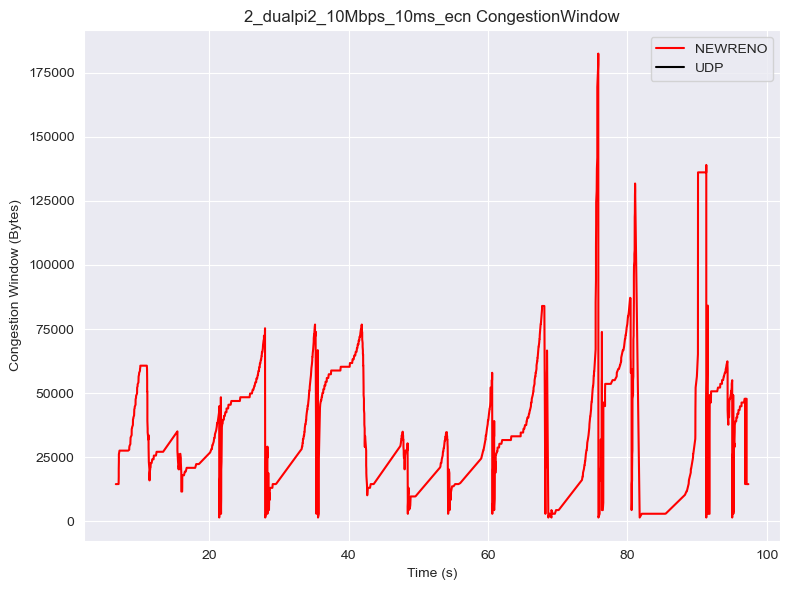


Start New Scenario
2_dualpi2_10Mbps_20ms_ecn
['../data/data_2025-04-11/client1_data\\2_dualpi2_10Mbps_20ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\2_dualpi2_10Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\2_dualpi2_10Mbps_20ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\2_dualpi2_10Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\2_dualpi2_10Mbps_20ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\2_dualpi2_10Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 2_dualpi2_10Mbps_20ms_ecn:
Statistics for NEWRENO:
Median: 316.562
Mean: 308.2999010791366
25th Percentile: 254.062
75th Percentile: 356.25
Minimum: 123.125
Maximum: 556.25
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END RTT *

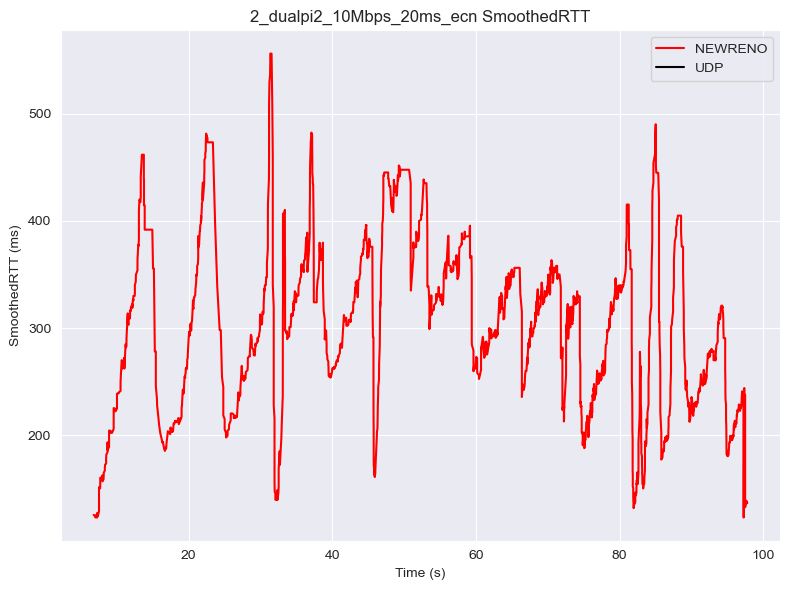

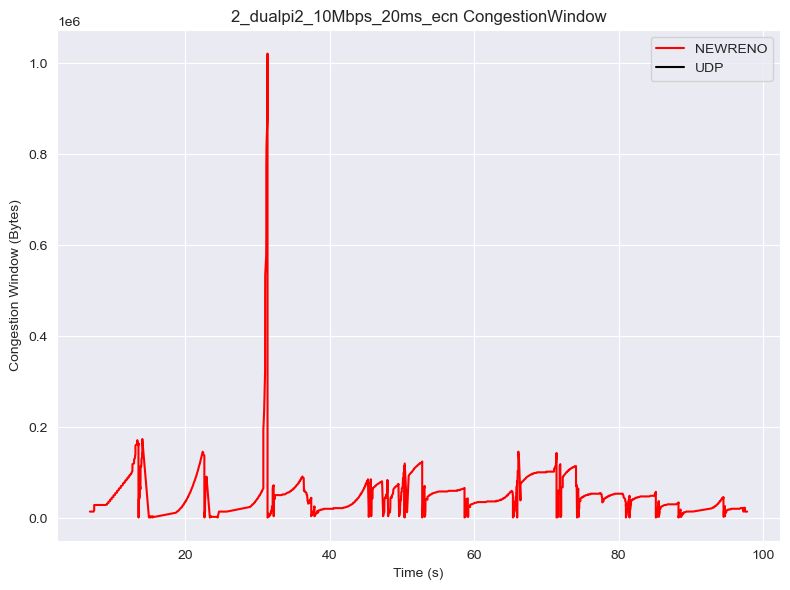


Start New Scenario
2_dualpi2_10Mbps_5ms_ecn
['../data/data_2025-04-11/client1_data\\2_dualpi2_10Mbps_5ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\2_dualpi2_10Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\2_dualpi2_10Mbps_5ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\2_dualpi2_10Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\2_dualpi2_10Mbps_5ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\2_dualpi2_10Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 2_dualpi2_10Mbps_5ms_ecn:
Statistics for NEWRENO:
Median: 226.25
Mean: 233.63327615334632
25th Percentile: 155.937
75th Percentile: 309.375
Minimum: 20.937
Maximum: 513.437
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END RTT *-*-*END

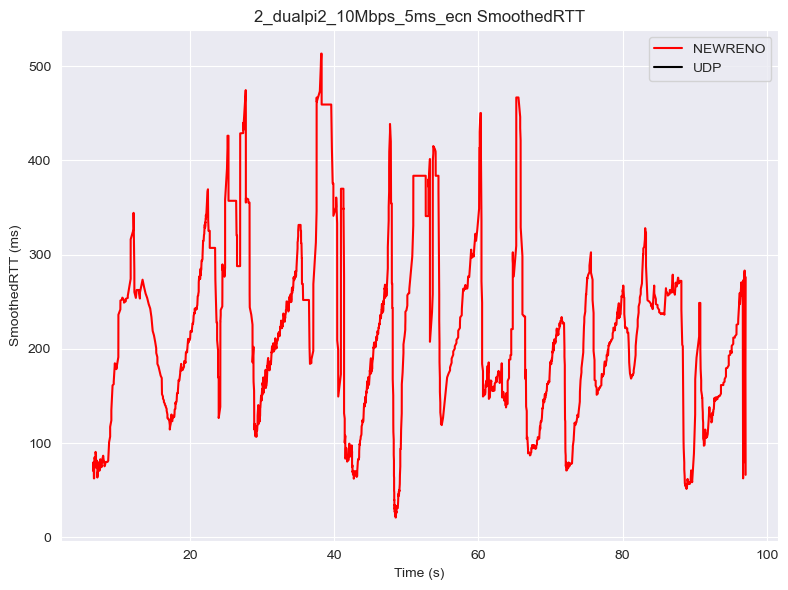

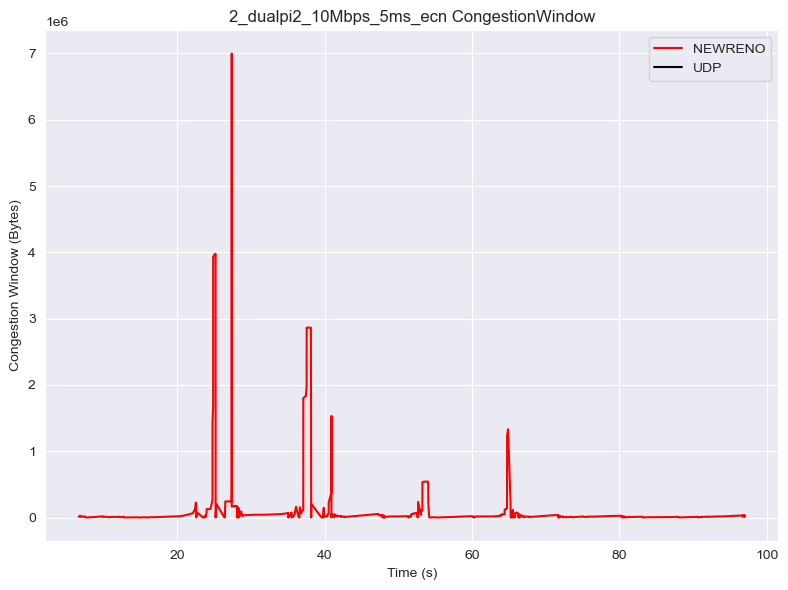


Start New Scenario
2_dualpi2_150Mbps_0ms_ecn
['../data/data_2025-04-11/client1_data\\2_dualpi2_150Mbps_0ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\2_dualpi2_150Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\2_dualpi2_150Mbps_0ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\2_dualpi2_150Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\2_dualpi2_150Mbps_0ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\2_dualpi2_150Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 2_dualpi2_150Mbps_0ms_ecn:
Statistics for NEWRENO:
Median: 22.187
Mean: 22.568043951767446
25th Percentile: 17.812
75th Percentile: 28.125
Minimum: 2.187
Maximum: 111.562
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END RTT *-*

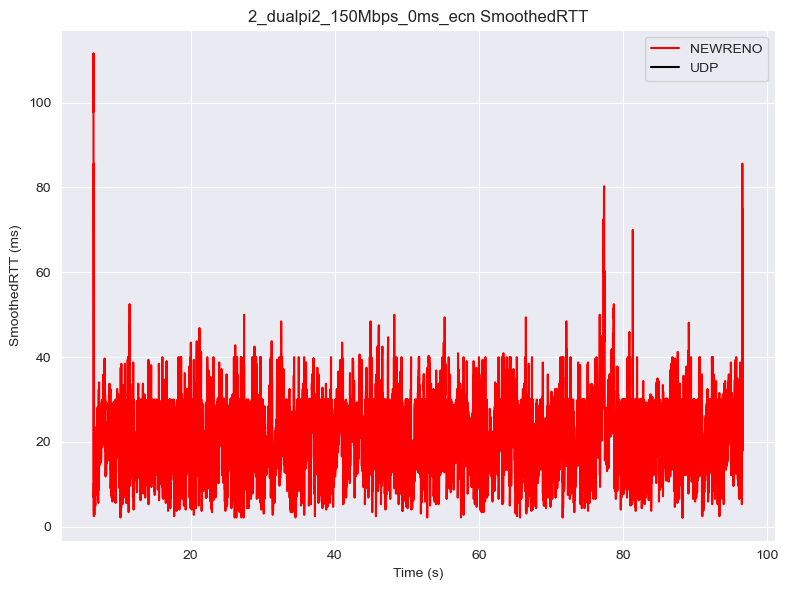

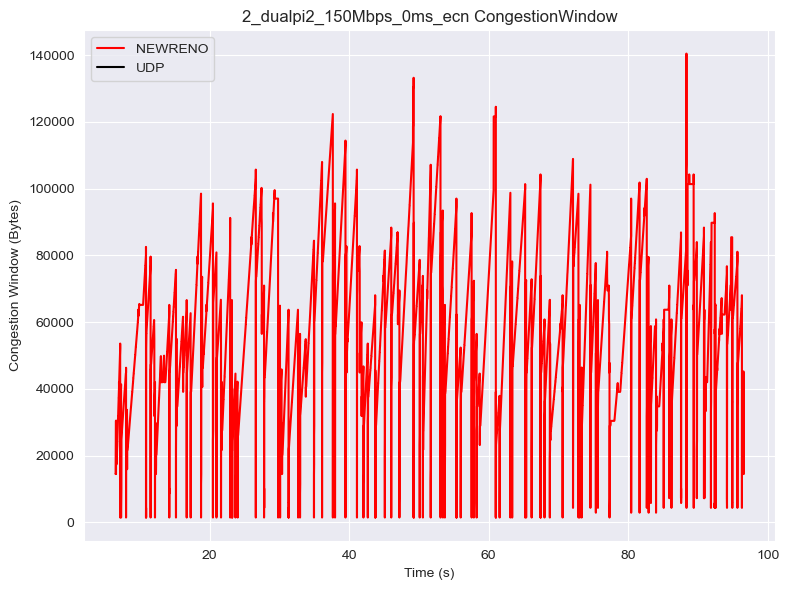


Start New Scenario
2_dualpi2_150Mbps_10ms_ecn
['../data/data_2025-04-11/client1_data\\2_dualpi2_150Mbps_10ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\2_dualpi2_150Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\2_dualpi2_150Mbps_10ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\2_dualpi2_150Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\2_dualpi2_150Mbps_10ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\2_dualpi2_150Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 2_dualpi2_150Mbps_10ms_ecn:
Statistics for NEWRENO:
Median: 134.375
Mean: 138.3688732560574
25th Percentile: 107.5
75th Percentile: 169.687
Minimum: 32.5
Maximum: 370.0
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END RT

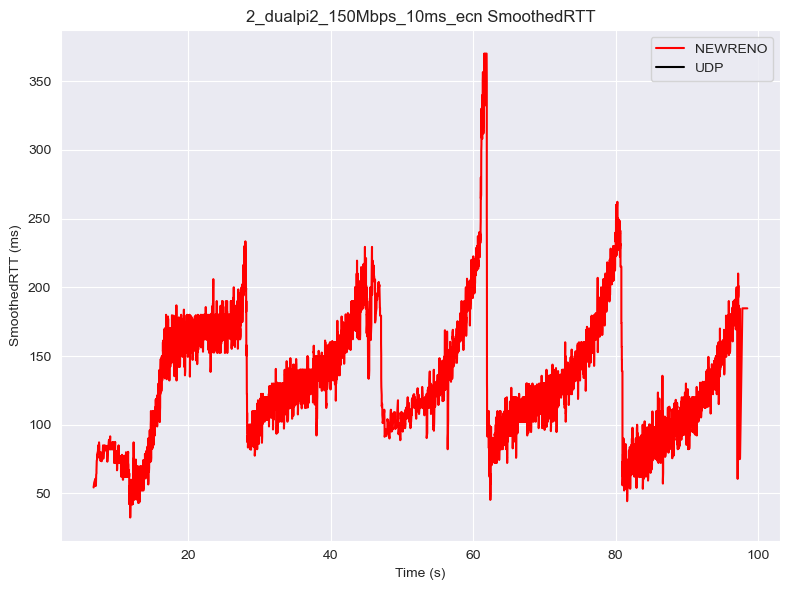

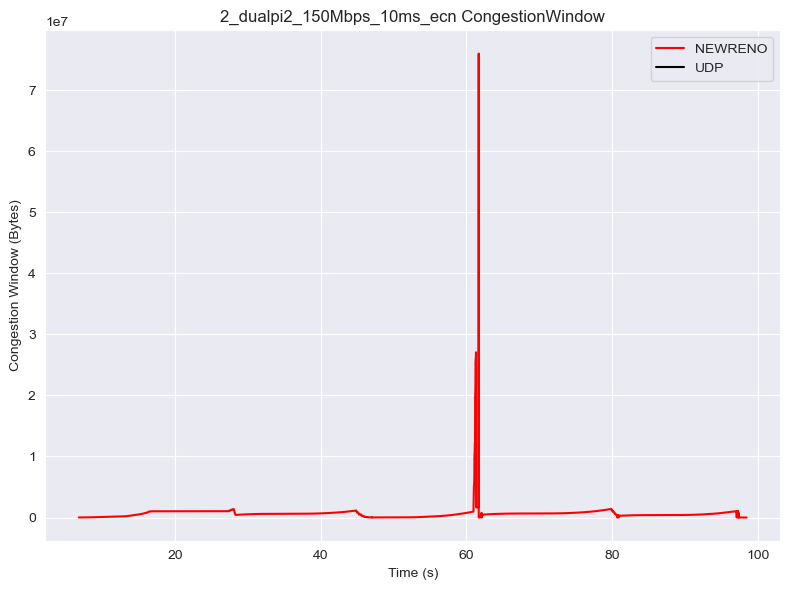


Start New Scenario
2_dualpi2_150Mbps_20ms_ecn
['../data/data_2025-04-11/client1_data\\2_dualpi2_150Mbps_20ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\2_dualpi2_150Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\2_dualpi2_150Mbps_20ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\2_dualpi2_150Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\2_dualpi2_150Mbps_20ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\2_dualpi2_150Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 2_dualpi2_150Mbps_20ms_ecn:
Statistics for NEWRENO:
Median: 172.187
Mean: 178.28917285250873
25th Percentile: 140.0
75th Percentile: 220.0
Minimum: 72.187
Maximum: 360.0
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END R

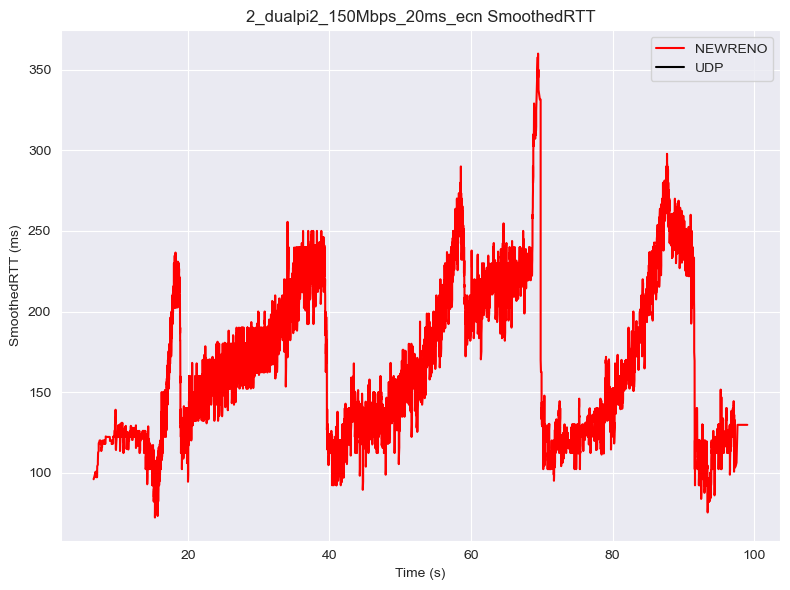

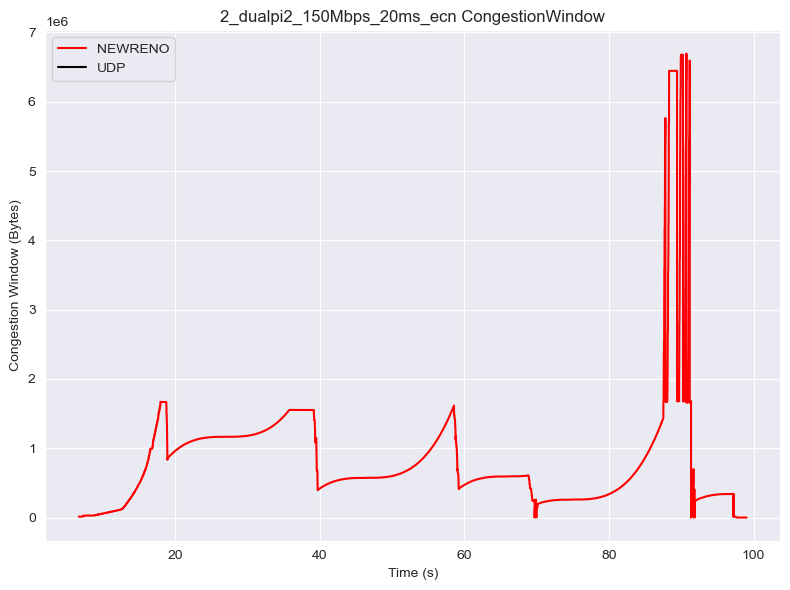


Start New Scenario
2_dualpi2_150Mbps_5ms_ecn
['../data/data_2025-04-11/client1_data\\2_dualpi2_150Mbps_5ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\2_dualpi2_150Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\2_dualpi2_150Mbps_5ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\2_dualpi2_150Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\2_dualpi2_150Mbps_5ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\2_dualpi2_150Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 2_dualpi2_150Mbps_5ms_ecn:
Statistics for NEWRENO:
Median: 23.437
Mean: 25.022481539145915
25th Percentile: 18.75
75th Percentile: 29.375
Minimum: 2.187
Maximum: 304.687
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END RTT *-*-

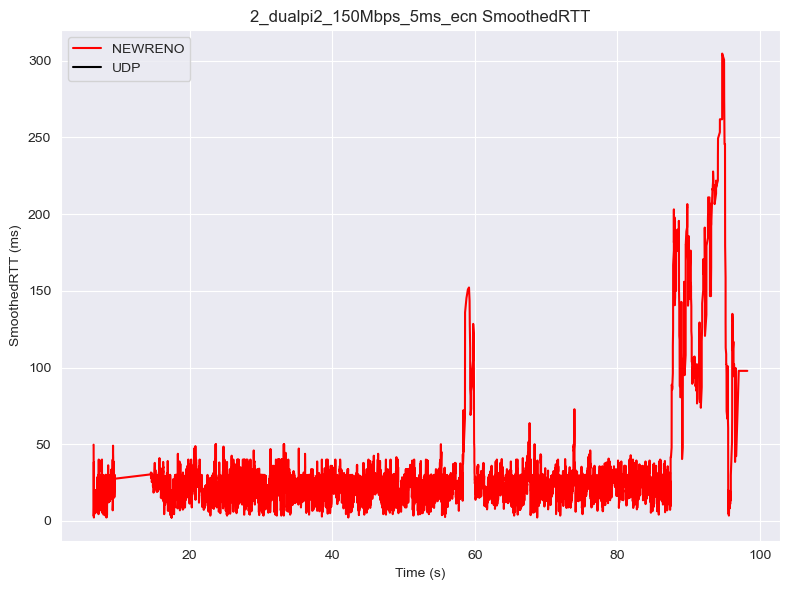

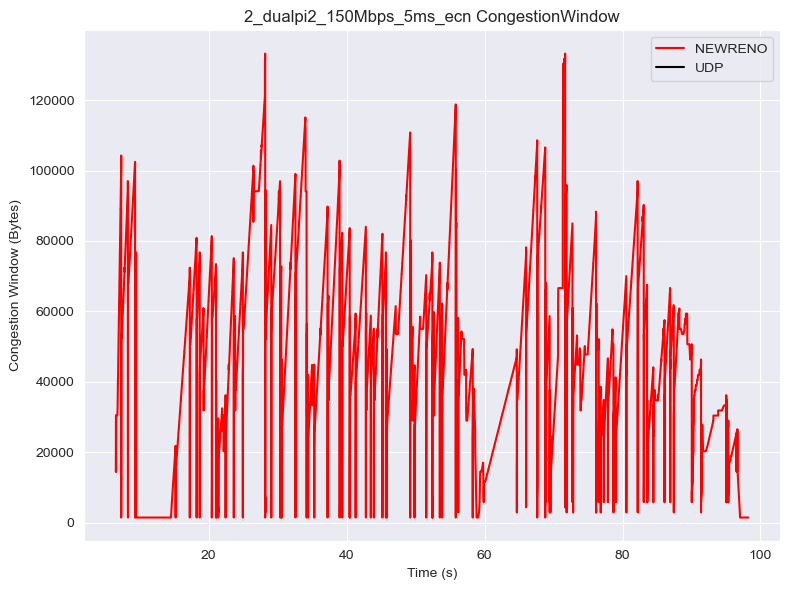


Start New Scenario
2_dualpi2_20Mbps_0ms_ecn
['../data/data_2025-04-11/client1_data\\2_dualpi2_20Mbps_0ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\2_dualpi2_20Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\2_dualpi2_20Mbps_0ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\2_dualpi2_20Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\2_dualpi2_20Mbps_0ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\2_dualpi2_20Mbps_0ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 2_dualpi2_20Mbps_0ms_ecn:
Statistics for NEWRENO:
Median: 67.812
Mean: 111.93664012982053
25th Percentile: 43.437
75th Percentile: 145.312
Minimum: 2.187
Maximum: 548.437
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END RTT *-*-*END R

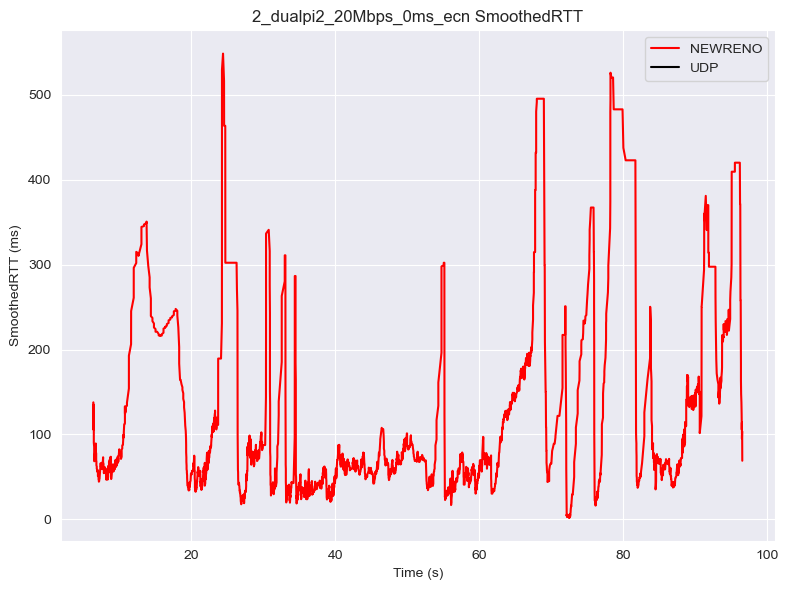

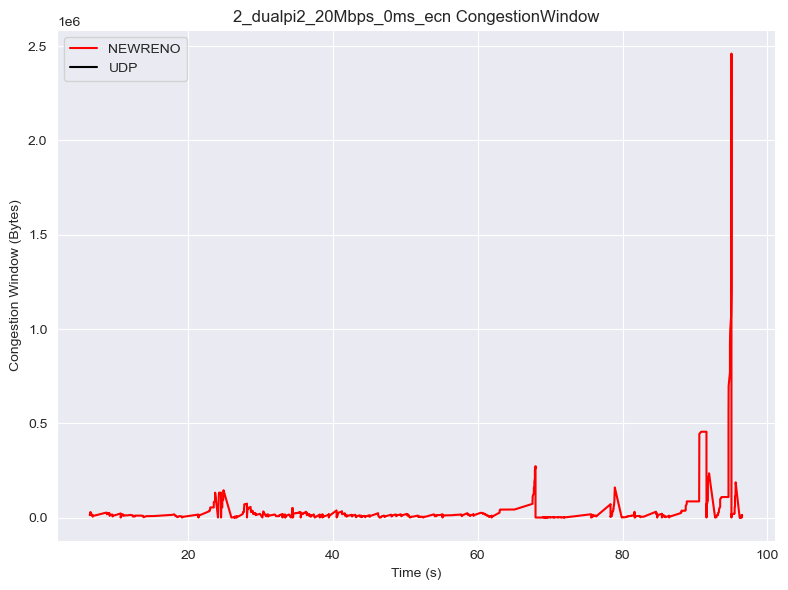


Start New Scenario
2_dualpi2_20Mbps_10ms_ecn
['../data/data_2025-04-11/client1_data\\2_dualpi2_20Mbps_10ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\2_dualpi2_20Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\2_dualpi2_20Mbps_10ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\2_dualpi2_20Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\2_dualpi2_20Mbps_10ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\2_dualpi2_20Mbps_10ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 2_dualpi2_20Mbps_10ms_ecn:
Statistics for NEWRENO:
Median: 212.187
Mean: 212.10266656444853
25th Percentile: 162.187
75th Percentile: 260.0
Minimum: 54.062
Maximum: 375.937
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END RTT *

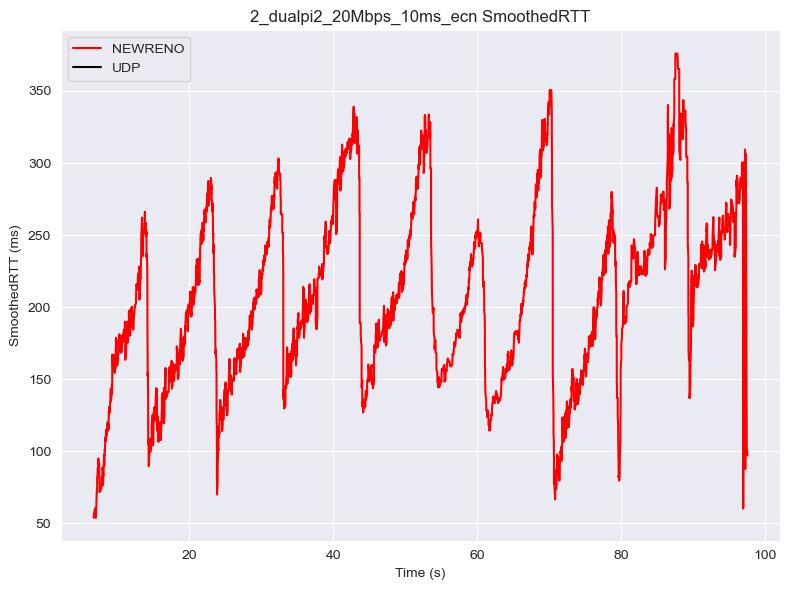

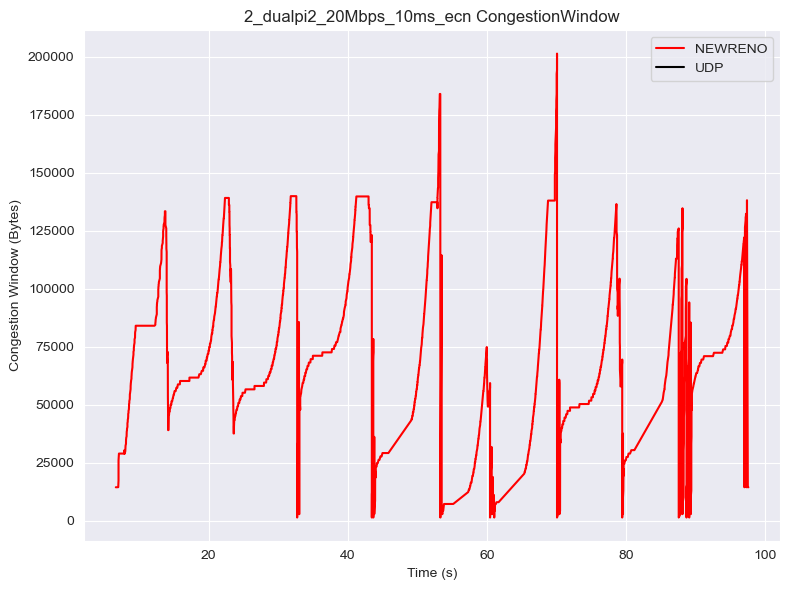


Start New Scenario
2_dualpi2_20Mbps_20ms_ecn
['../data/data_2025-04-11/client1_data\\2_dualpi2_20Mbps_20ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\2_dualpi2_20Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\2_dualpi2_20Mbps_20ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\2_dualpi2_20Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\2_dualpi2_20Mbps_20ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\2_dualpi2_20Mbps_20ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 2_dualpi2_20Mbps_20ms_ecn:
Statistics for NEWRENO:
Median: 224.375
Mean: 228.36673769168684
25th Percentile: 180.312
75th Percentile: 274.375
Minimum: 99.687
Maximum: 497.812
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END RTT

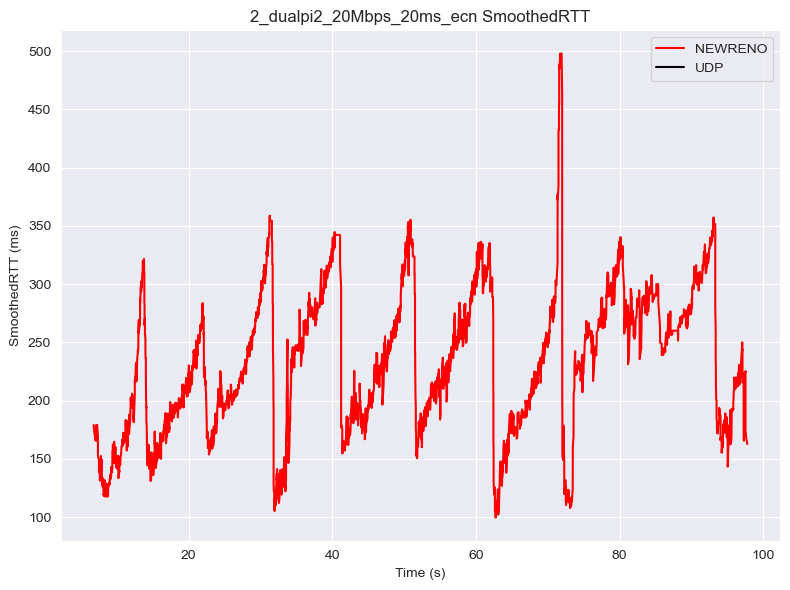

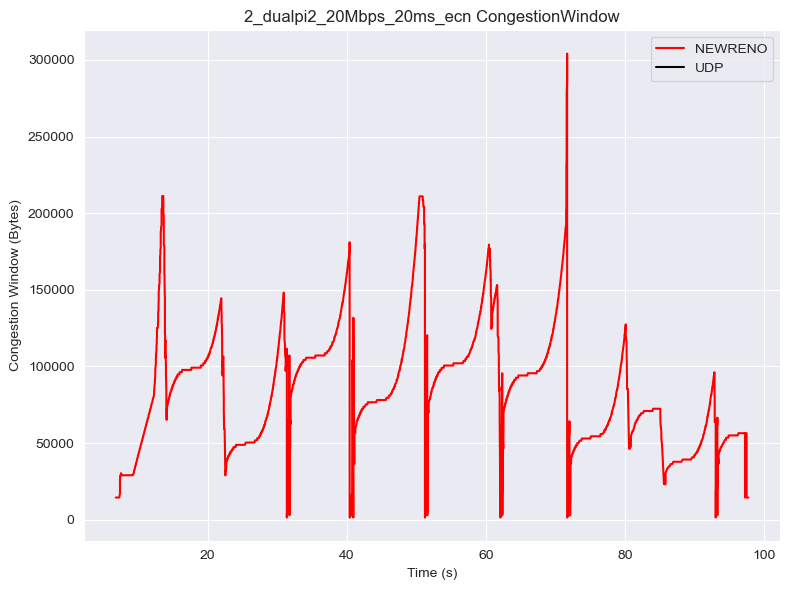


Start New Scenario
2_dualpi2_20Mbps_5ms_ecn
['../data/data_2025-04-11/client1_data\\2_dualpi2_20Mbps_5ms_ecn_tcp_newreno_src1.siftr.log', '../data/data_2025-04-11/client2_data\\2_dualpi2_20Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log']
tcp_traffic ../data/data_2025-04-11/client1_data\2_dualpi2_20Mbps_5ms_ecn_tcp_newreno_src1.siftr.log
udp_traffic ../data/data_2025-04-11/client2_data\2_dualpi2_20Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log
../data/data_2025-04-11/client1_data\2_dualpi2_20Mbps_5ms_ecn_tcp_newreno_src1.siftr.log
../data/data_2025-04-11/client2_data\2_dualpi2_20Mbps_5ms_ecn_tcp_dctcp_src2.siftr.log

RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*RTT *-*-*
RTT statistics in millisecond (ms) for scenario 2_dualpi2_20Mbps_5ms_ecn:
Statistics for NEWRENO:
Median: 197.812
Mean: 192.12448095849376
25th Percentile: 100.0
75th Percentile: 245.0
Minimum: 29.687
Maximum: 602.187
Statistics for UDP:
Median: nan
Mean: nan
25th Percentile: nan
75th Percentile: nan
Minimum: nan
Maximum: nan
END RTT *-*-*END RT

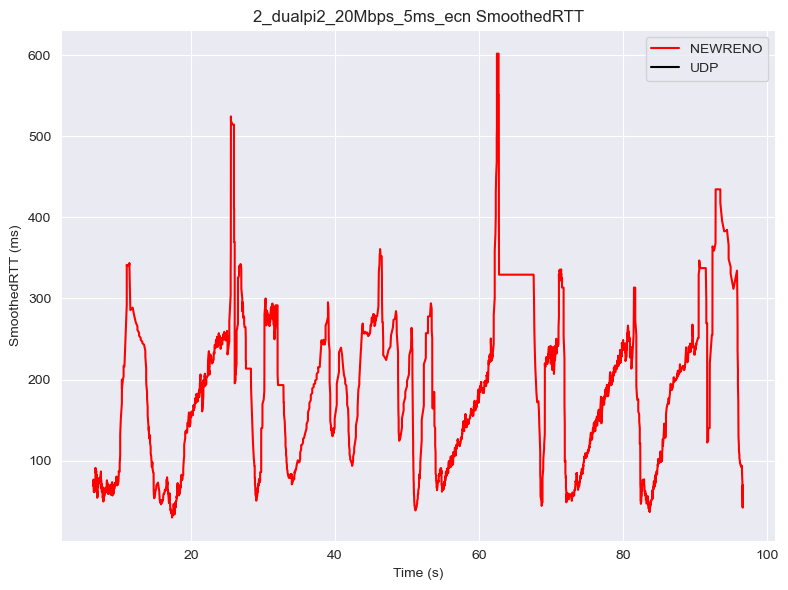

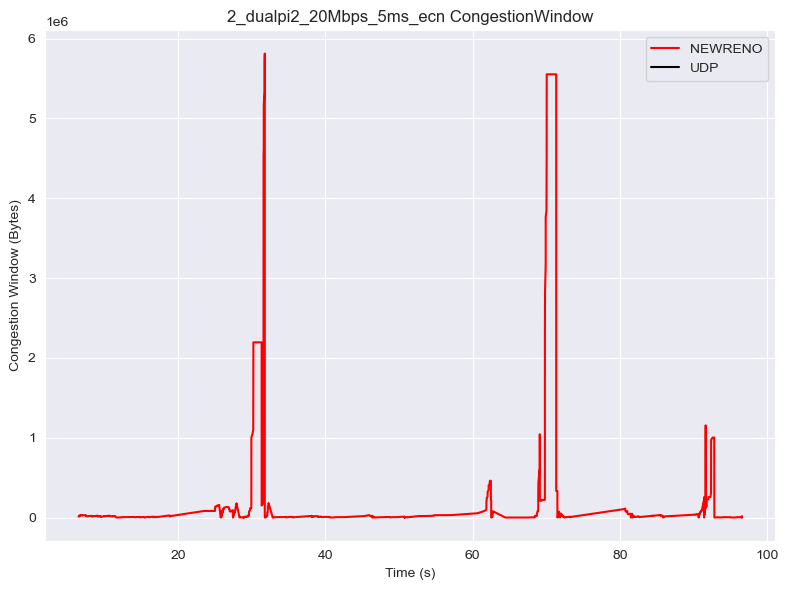

In [11]:
for scenario in unique_scenarios_dict.keys():

    print()
    print("Start New Scenario")
    print(scenario)
    print(unique_scenarios_dict[scenario])

    tcp_traffic = unique_scenarios_dict[scenario][0]
    udp_traffic = unique_scenarios_dict[scenario][1]

    print("tcp_traffic",tcp_traffic)
    print("udp_traffic",udp_traffic)


    ttf = get_dataframe_from_filepath(tcp_traffic)
    utf = get_dataframe_from_filepath(udp_traffic)

    ttf = ttf[ttf['ForeignPort'] == "5101"]
    utf = utf[utf['ForeignPort'] == "5101"]

    # Define paths
    paths = {
        "NEWRENO": ttf,
        "UDP": utf,
    }

    print_rtt_stats(paths=paths,scenario=scenario)
    save_rtt_stats(paths=paths,scenario=scenario,stats_directory=stats_directory)



    plot_siftr_graph(paths=paths,
                    ycolumn="SmoothedRTT",
                    title=f"{scenario} SmoothedRTT",
                    xlabel="Time (s)",
                    ylabel="SmoothedRTT (ms)",
                    filename=f'{scenario}_SmoothedRTT',
                    graph_directory=graph_directory,
    )




    plot_siftr_graph(paths=paths,
                    ycolumn="CongestionWindow",
                    title=f"{scenario} CongestionWindow",
                    xlabel="Time (s)",
                    ylabel="Congestion Window (Bytes)",
                    filename=f'{scenario}_CWND',
                    graph_directory=graph_directory,
    )
